In [4]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import ConcatDataset

import numpy as np
import matplotlib.pyplot as plt

from ViTGSOM import AutoEncoder, ViTLossReconstruction, SomLoss
from help_functions import get_grid_coords, decay_exponential, calculate_QE_TE_Purity, plot_umap_som_weights, get_node_hits, plot_som_weights, plot_som_mnist, plot_som_pie_grid

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(), 
])


train_set = datasets.USPS(root="./data", train=True, download=True, transform=transform)
test_set = datasets.USPS(root="./data", train=False, download=True, transform=transform)
dataset = ConcatDataset([train_set, test_set])

In [6]:
dataset

In [7]:
config = {
    'img_size': 16,
    'patch_size': 4,
    'num_of_channels': 1,
    'embed_dim': 16,
    'enc_depth': 4,
    'dec_depth': 2,
    'num_heads': 2,
    'mlp_dim': 64,
    'epochs_pretrain': 20,
    'epochs_som': 500,
    'fine_tuning_epochs': 100,
    'lr': 0.0005,
    'grow_after_epochs': 10,
    'som_rows': 5,
    'som_cols': 5,
    'stop_growth_purity': 0.90
}

In [8]:
autoencoder = AutoEncoder(img_size=config['img_size'], 
                          patch_size=config['patch_size'], 
                          num_of_channels=config['num_of_channels'], 
                          embed_dim=config['embed_dim'], 
                          enc_depth=config['enc_depth'],                                      
                          dec_depth=config['dec_depth'], 
                          num_heads=config['num_heads'], 
                          mlp_dim=config['mlp_dim'],
                          som_rows=config['som_rows'],
                          som_cols=config['som_cols'])    

In [9]:
criterionViT = ViTLossReconstruction()
criterionSOM = SomLoss()

loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

autoencoder.to(device)
autoencoder.train()

AutoEncoder(
  (encoder): ViTEncoder(
    (patch_embed): PatchEmbedding(
      (proj): Conv2d(1, 16, kernel_size=(4, 4), stride=(4, 4))
    )
    (blocks): ModuleList(
      (0-3): 4 x Block(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
        (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (dense_1): Linear(in_features=16, out_features=64, bias=True)
          (activation): GELU(approximate='none')
          (dense_2): Linear(in_features=64, out_features=16, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ln2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      )
    )
    (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): ViTDecoder(
    (blocks): ModuleList(
      (0-1): 2 x Block(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLine

## Phase 1: Pretrain ViT

In [10]:
autoencoder.som_weights.requires_grad = False
for param in autoencoder.encoder.parameters():
    param.requires_grad = True
for param in autoencoder.decoder.parameters():
    param.requires_grad = True
    
paramsViT = list(autoencoder.encoder.parameters()) + list(autoencoder.decoder.parameters())
optimizerViT = optim.AdamW(paramsViT, lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerViT, T_max=config['epochs_pretrain'])

history = {'MSE': []}

for epoch in range(config['epochs_pretrain']):
    running_mse = 0.0
    
    for images, _ in loader:
        images = images.to(device)
        
        reconstructed, latent, _ = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_nn = criterionViT(images, reconstructed)
        
        optimizerViT.zero_grad()
        l_nn.backward()
        optimizerViT.step()
        running_mse += l_nn.item()
        
    scheduler.step()
    history['MSE'].append(running_mse/len(loader))
        
    print(f"Epoch {epoch+1}/{config['epochs_pretrain']}: MSE Loss {running_mse/len(loader):.8f}")

Epoch 1/20: MSE Loss 0.06295908
Epoch 2/20: MSE Loss 0.00994654
Epoch 3/20: MSE Loss 0.00579285
Epoch 4/20: MSE Loss 0.00433137
Epoch 5/20: MSE Loss 0.00340984
Epoch 6/20: MSE Loss 0.00274014
Epoch 7/20: MSE Loss 0.00224329
Epoch 8/20: MSE Loss 0.00190080
Epoch 9/20: MSE Loss 0.00167455
Epoch 10/20: MSE Loss 0.00150813
Epoch 11/20: MSE Loss 0.00138390
Epoch 12/20: MSE Loss 0.00128980
Epoch 13/20: MSE Loss 0.00121555
Epoch 14/20: MSE Loss 0.00115491
Epoch 15/20: MSE Loss 0.00111349
Epoch 16/20: MSE Loss 0.00108309
Epoch 17/20: MSE Loss 0.00106136
Epoch 18/20: MSE Loss 0.00104511
Epoch 19/20: MSE Loss 0.00103358
Epoch 20/20: MSE Loss 0.00103098


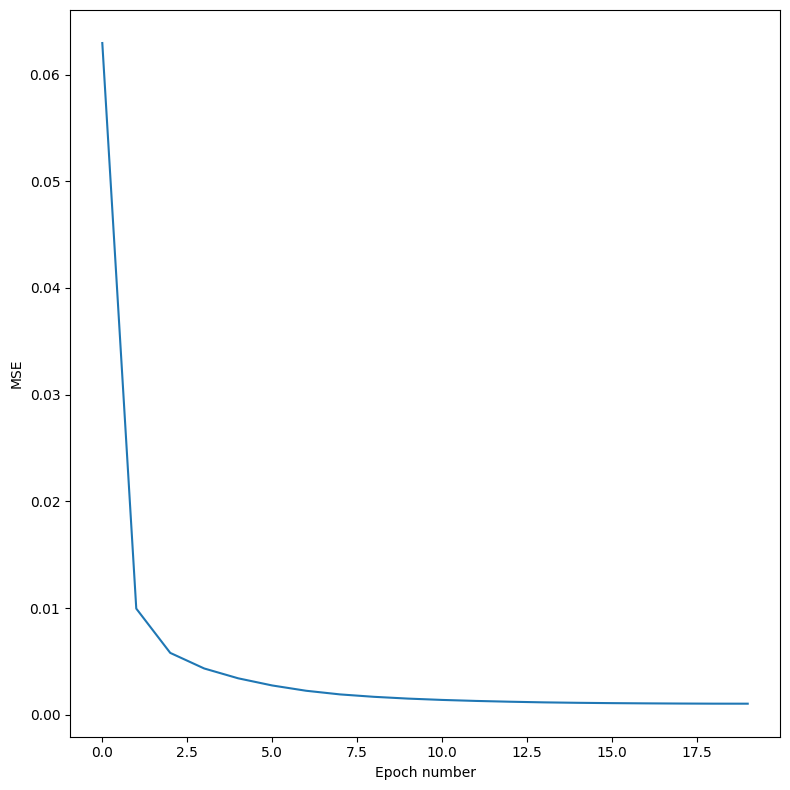

In [11]:
plt.figure(figsize=(8, 8))
plt.plot(np.arange(config['epochs_pretrain']), history['MSE'])
plt.ylabel('MSE')
plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

## Phase 2: GSOM training

In [27]:
torch.save(autoencoder, "D:/Tom/ViT-GHSOM/model_usps_early.pth")

In [7]:
autoencoder = torch.load("D:/Tom/ViT-GHSOM/model_fmnist_early.pth",weights_only=False)

In [12]:
autoencoder.som_weights.requires_grad = True
for param in autoencoder.encoder.parameters():
    param.requires_grad = False
for param in autoencoder.decoder.parameters():
    param.requires_grad = False

paramsSOM = autoencoder.som_weights
optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['epochs_som'])

sigma_start = autoencoder.get_sigma()
sigma_end = 0.3
beta = (sigma_end / sigma_start) ** (1 / config['grow_after_epochs'])
epochs_since_reset = 0

grid_coords = get_grid_coords(config['som_rows'], config['som_cols'], device)
current_sigma = sigma_start

history = {'som': [], 'purity': [], 'QE': [], 'TE': []}


snapshot_som_weights = {}
snapshot_som_weights[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

unique_labels = set()

print("Start GSOM training")
for epoch in range(config['epochs_som']):
    
    running_som = 0.0
    
    sigma_t = decay_exponential(sigma_start, beta, epochs_since_reset)

    for images, labels in loader:
        images = images.to(device)
        unique_labels.update(labels.tolist())
        
        reconstructed, latent, _ = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        
        optimizerSOM.zero_grad()
        l_som.backward()
        optimizerSOM.step()
        
        running_som += l_som.item()
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()

    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_som = running_som / len(loader)

    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config['epochs_som']} | Sigma: {sigma_t:.3f} | SOM: {avg_som:.8f}) | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")
        
    if epoch > 0 and (epoch + 1) % config['grow_after_epochs'] == 0:     
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights[epoch+1] = (weights_np, labels_np)

        if metrics["Purity"] > config['stop_growth_purity']:
            print(f"Purity is high enough: {metrics["Purity"]}, entering Phase 3 - Fine-tuning")
            break
        
        epochs_since_reset += 1
        autoencoder.start_growth(loader, device)
        paramsSOM = autoencoder.get_som_weights()
        optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])

        for param_group in optimizerSOM.param_groups: param_group['initial_lr'] = config['lr']

        scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['epochs_som'], last_epoch=epoch)
        grid_coords = get_grid_coords(autoencoder.current_row_num, autoencoder.current_col_num, device)

        sigma_start = autoencoder.get_sigma()
        sigma_start = max(sigma_start, 2.0)
        beta = (sigma_end / sigma_start) ** (1 / max(1, config['grow_after_epochs']))
        epochs_since_reset = 0

    else:
        epochs_since_reset += 1   

Start GSOM training
Epoch 1/500 | Sigma: 3.000 | SOM: 17.11970349) | QE: 0.7759 | TE: 0.8838 | Purity: 0.23951
Epoch 2/500 | Sigma: 2.383 | SOM: 13.11818253) | QE: 0.6796 | TE: 0.7640 | Purity: 0.22145
Epoch 3/500 | Sigma: 1.893 | SOM: 9.66686897) | QE: 0.5865 | TE: 0.3560 | Purity: 0.18208
Epoch 4/500 | Sigma: 1.504 | SOM: 6.59336151) | QE: 0.5007 | TE: 0.1252 | Purity: 0.17778
Epoch 5/500 | Sigma: 1.194 | SOM: 4.20586683) | QE: 0.4250 | TE: 0.0073 | Purity: 0.17660
Epoch 6/500 | Sigma: 0.949 | SOM: 2.55301109) | QE: 0.3595 | TE: 0.0001 | Purity: 0.17068
Epoch 7/500 | Sigma: 0.754 | SOM: 1.47460625) | QE: 0.3030 | TE: 0.0000 | Purity: 0.16713
Epoch 8/500 | Sigma: 0.599 | SOM: 0.80494604) | QE: 0.2550 | TE: 0.0000 | Purity: 0.16703
Epoch 9/500 | Sigma: 0.475 | SOM: 0.42550466) | QE: 0.2147 | TE: 0.0000 | Purity: 0.16703
Epoch 10/500 | Sigma: 0.378 | SOM: 0.24444916) | QE: 0.1818 | TE: 0.0000 | Purity: 0.16703
Current grid size: (5, 6)
Epoch 11/500 | Sigma: 3.000 | SOM: 10.05607294) | Q

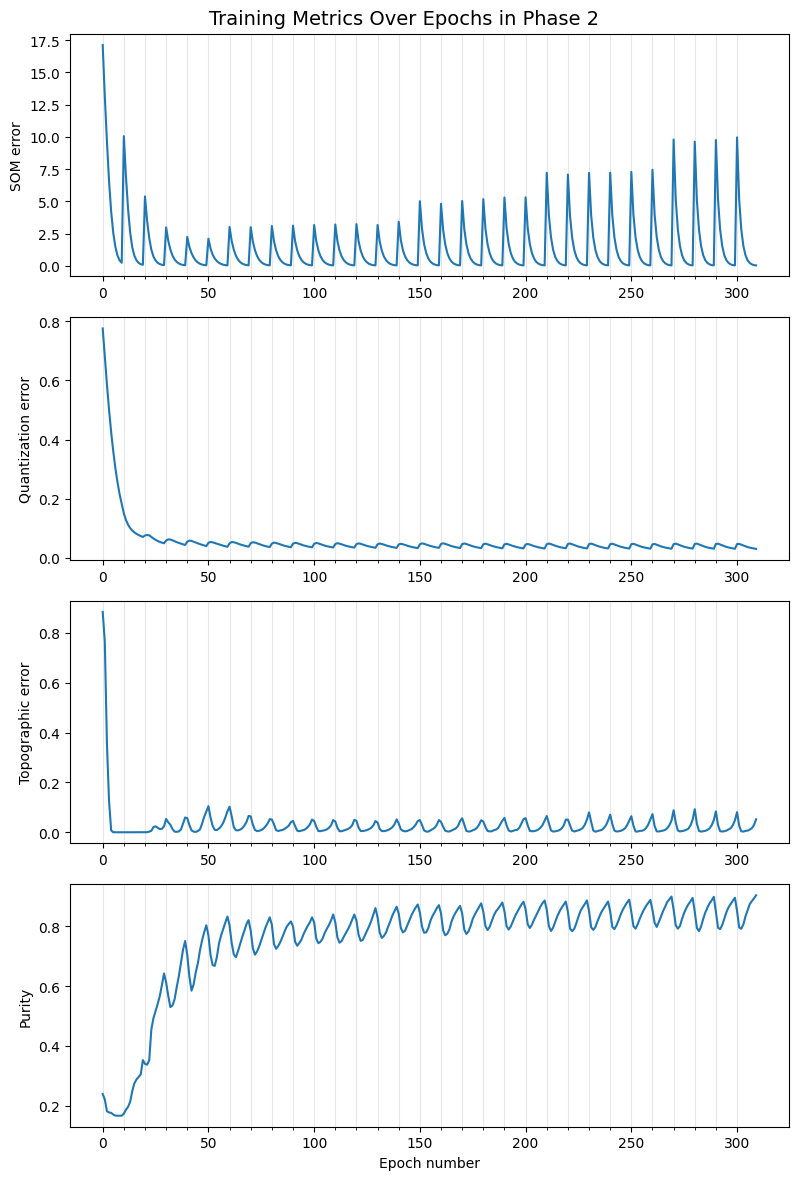

In [42]:
epochs_completed = len(history['QE'])
x = np.arange(epochs_completed)
xticks = np.arange(0, epochs_completed, 10)

plt.figure(figsize=(8, 12))

ax = plt.subplot(4,1,1)
plt.plot(x, history['som'])
plt.ylabel('SOM error')
ax.set_xticks(xticks, minor=True)
ax.grid(True, which='both', axis='x', linestyle='-', alpha=0.3)


ax = plt.subplot(4,1,2)
plt.plot(x, history['QE'])
plt.ylabel('Quantization error')
ax.set_xticks(xticks, minor=True)
ax.grid(True, which='both', axis='x', linestyle='-', alpha=0.3)

ax = plt.subplot(4,1,3)
plt.plot(x, history['TE'])
plt.ylabel('Topographic error')
ax.set_xticks(xticks, minor=True)
ax.grid(True, which='both', axis='x', linestyle='-', alpha=0.3)

ax = plt.subplot(4,1,4)
plt.plot(x, history['purity'])
plt.ylabel('Purity')
ax.set_xticks(xticks, minor=True)
ax.grid(True, which='both', axis='x', linestyle='-', alpha=0.3)

plt.xlabel('Epoch number')
plt.suptitle("Training Metrics Over Epochs in Phase 2", fontsize=14)
plt.tight_layout()
plt.show()

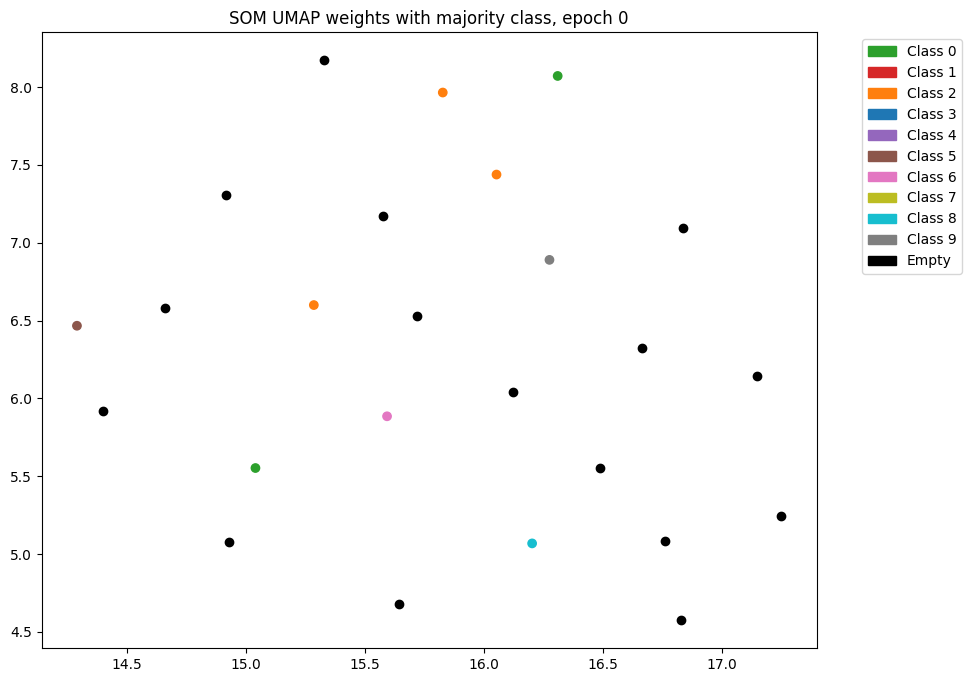

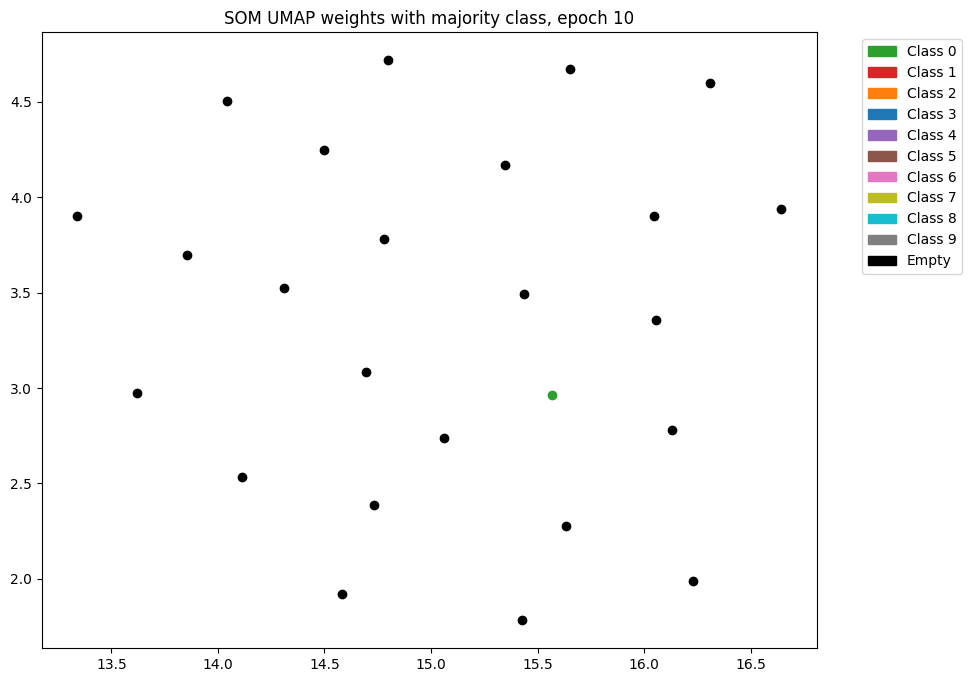

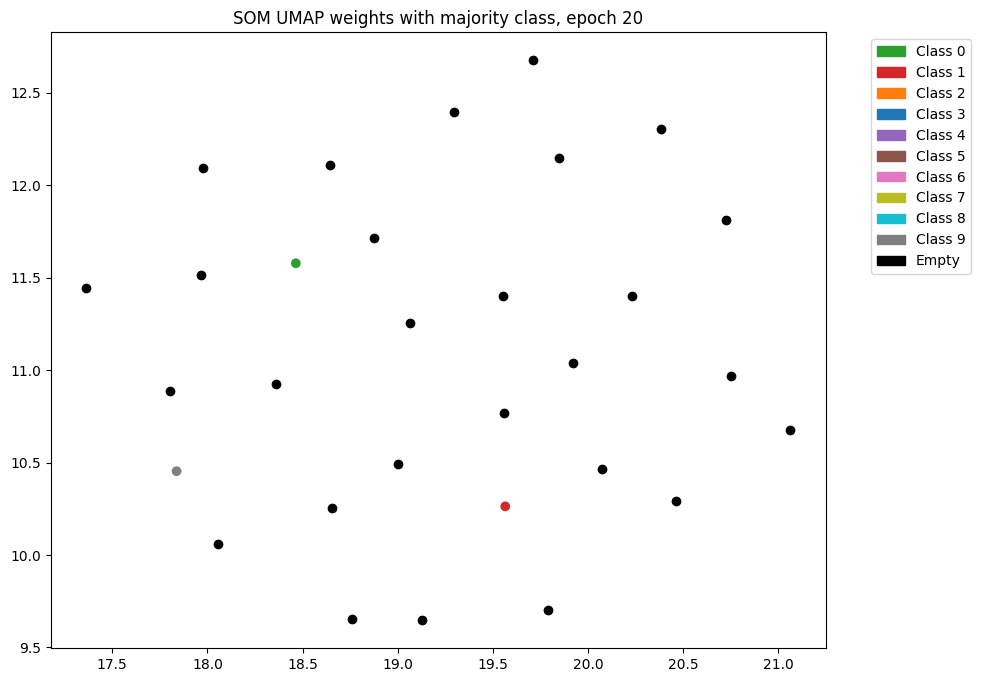

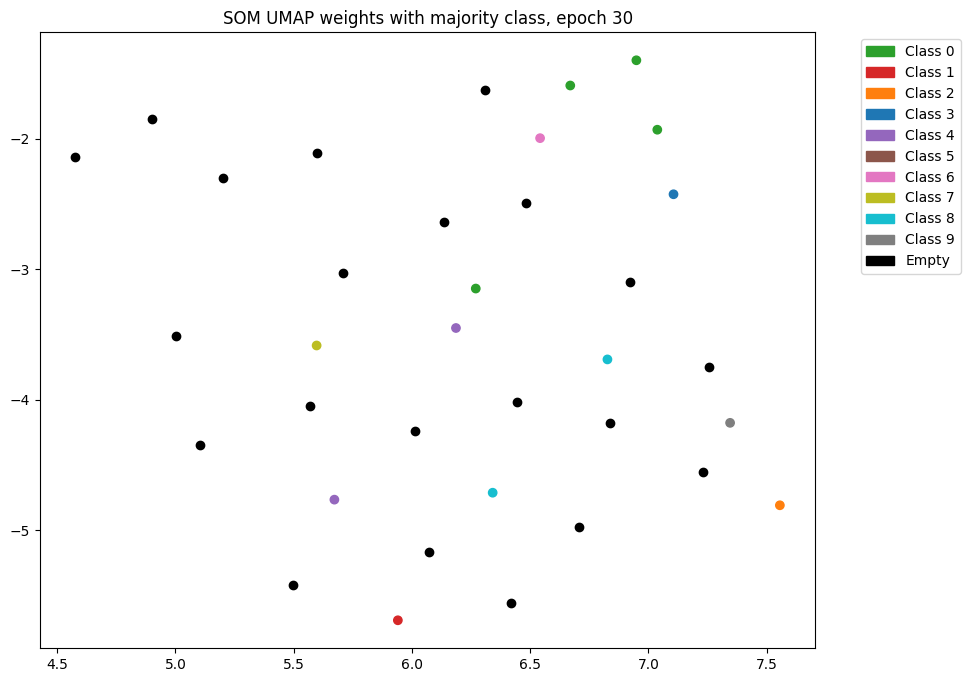

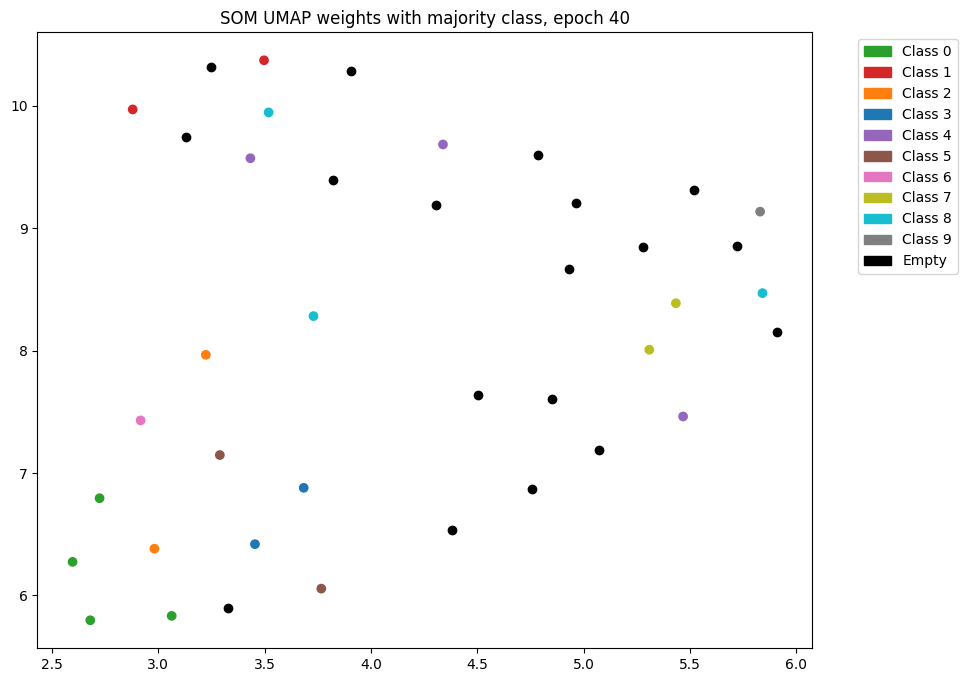

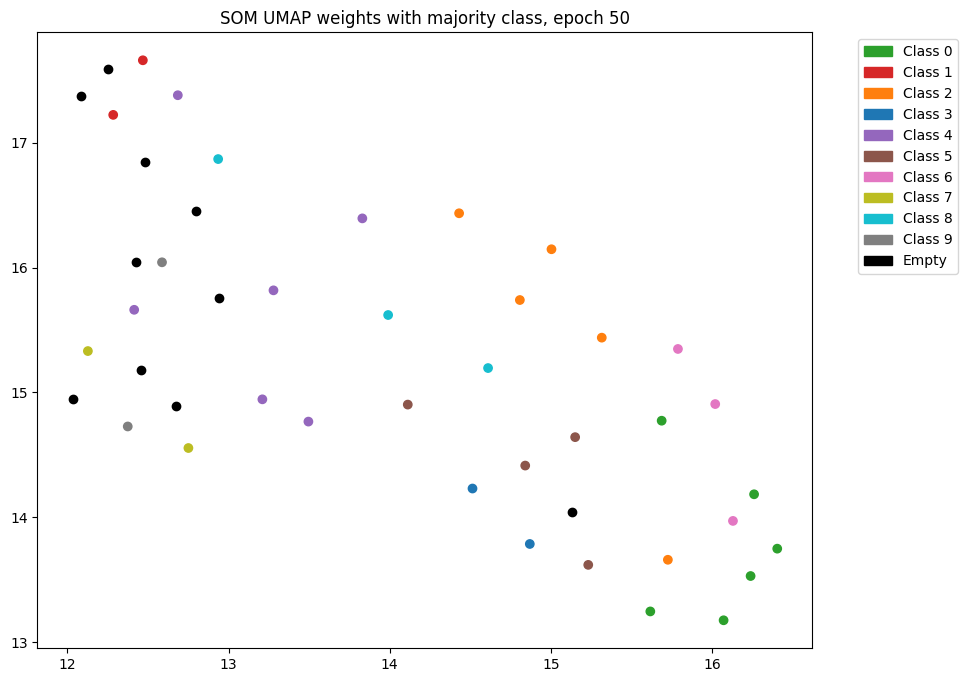

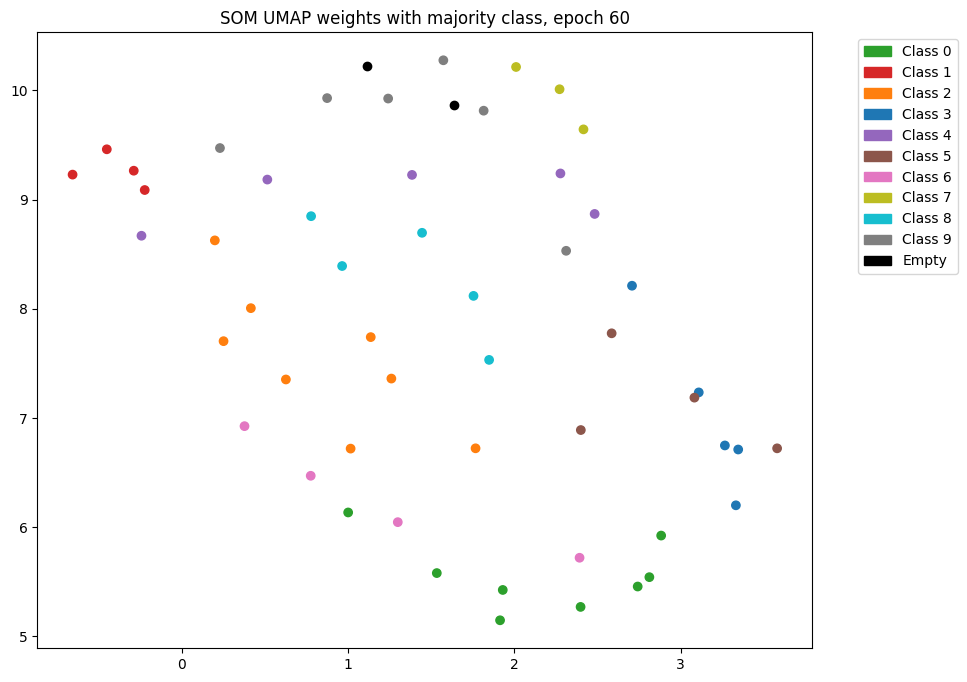

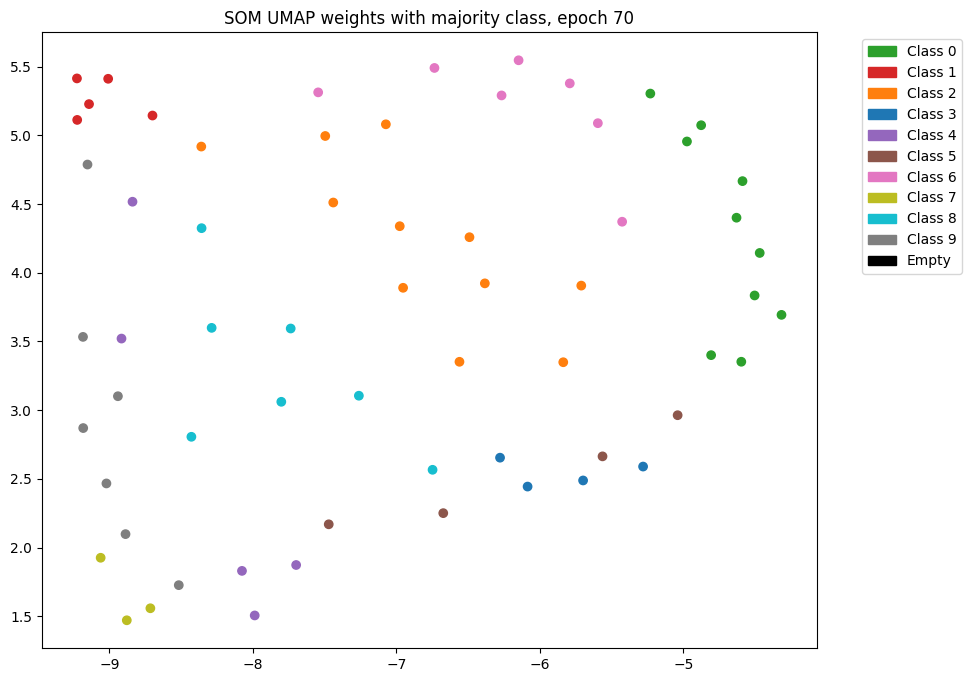

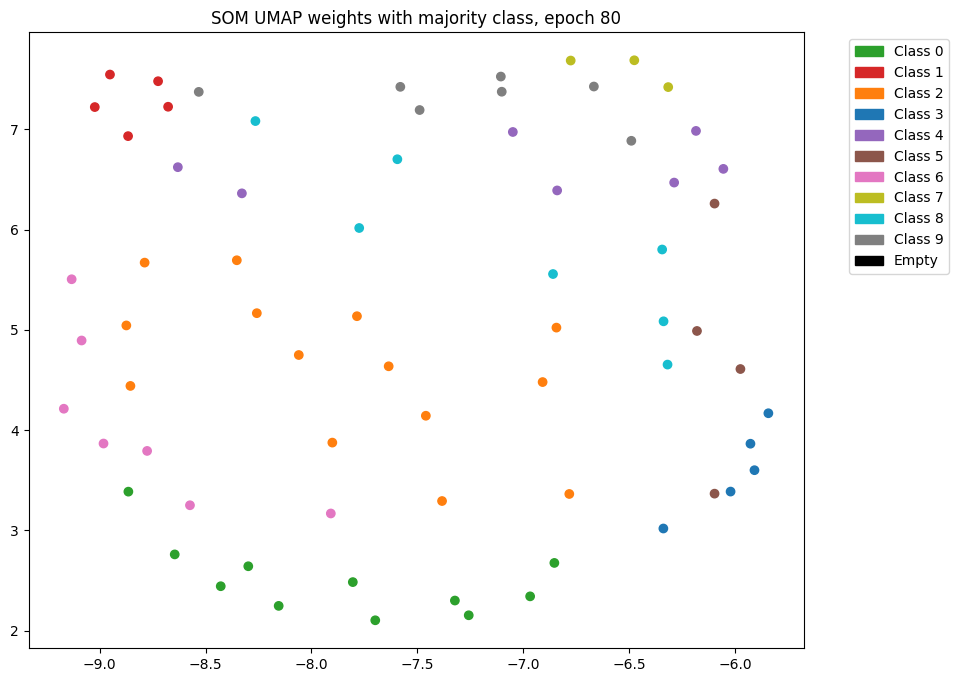

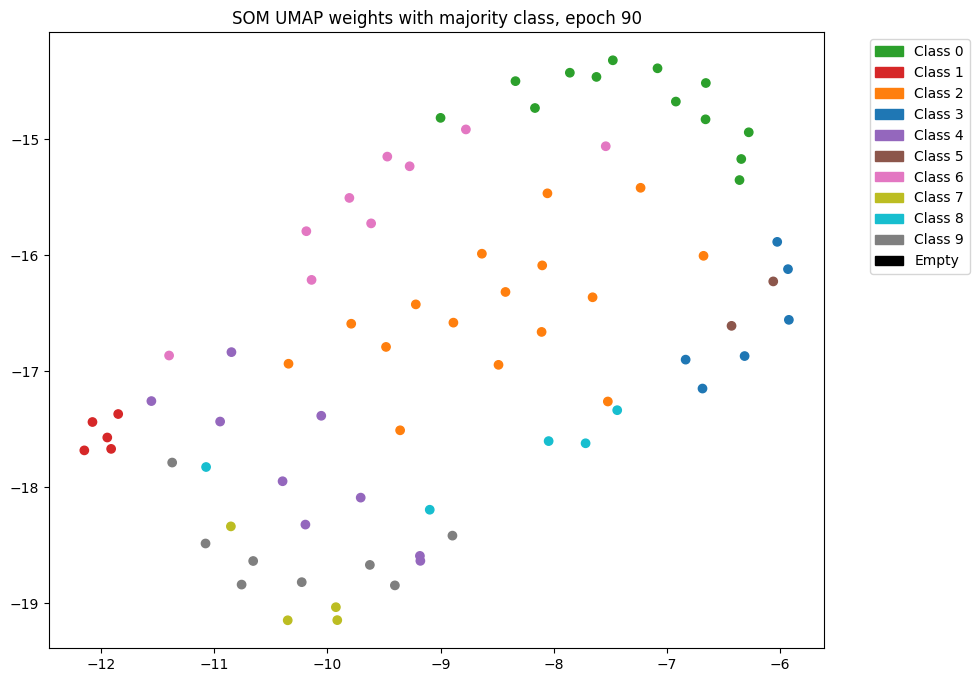

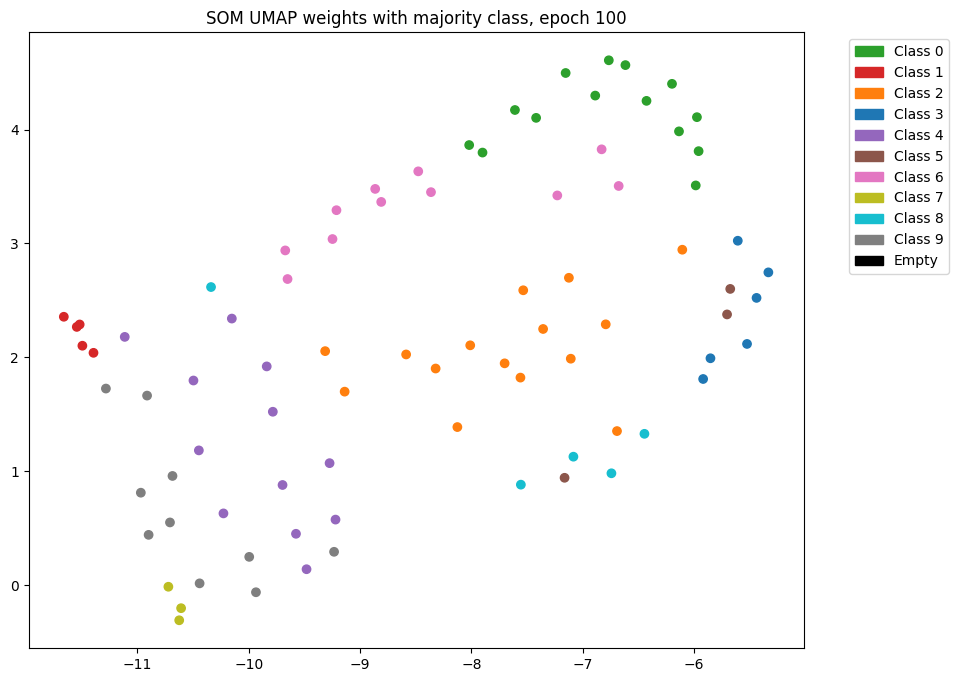

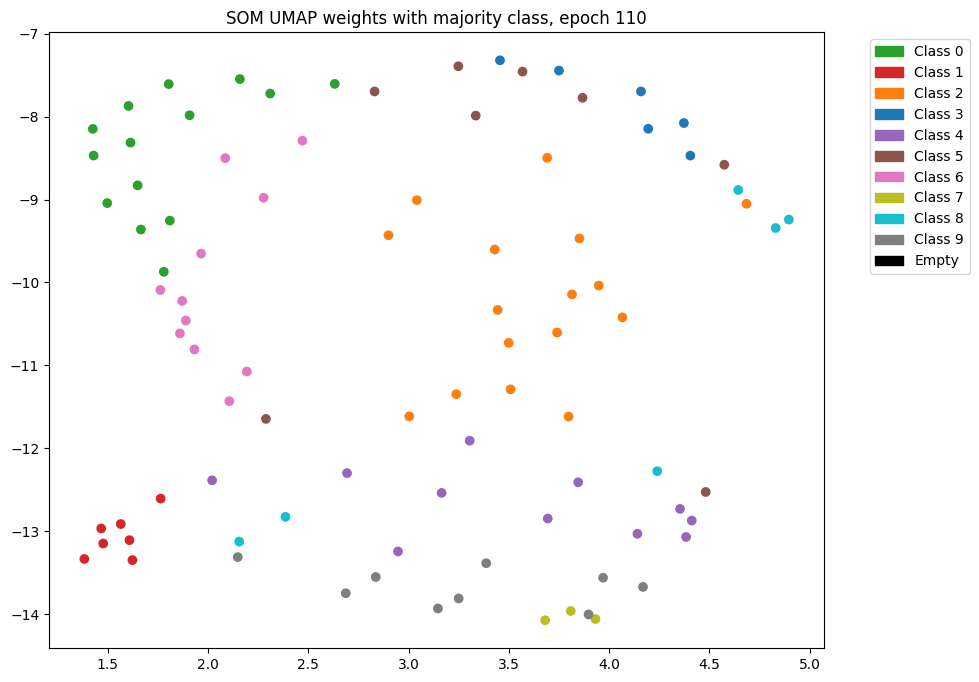

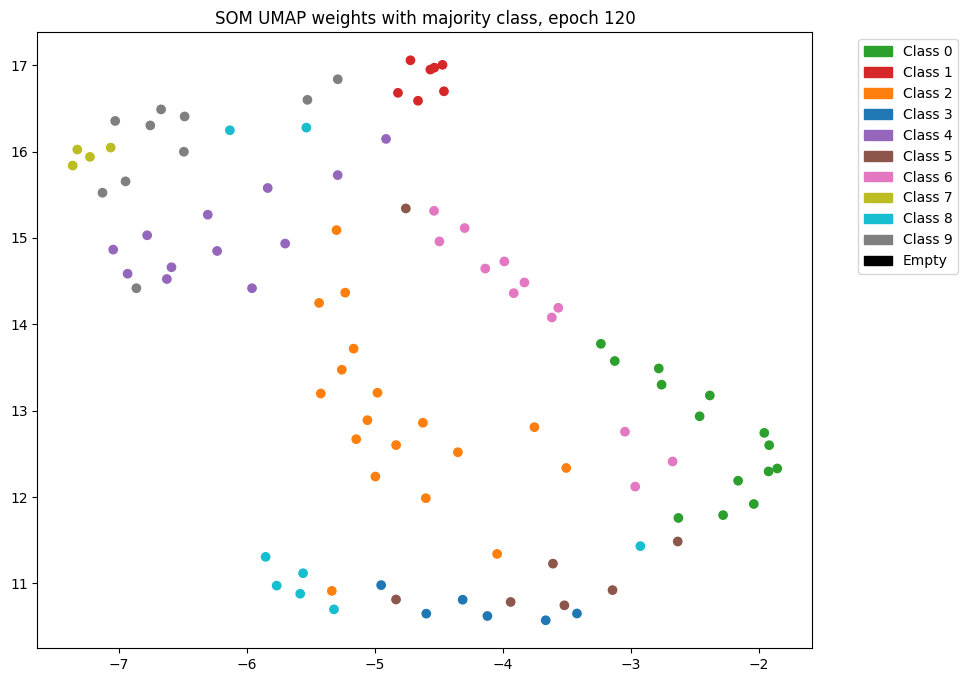

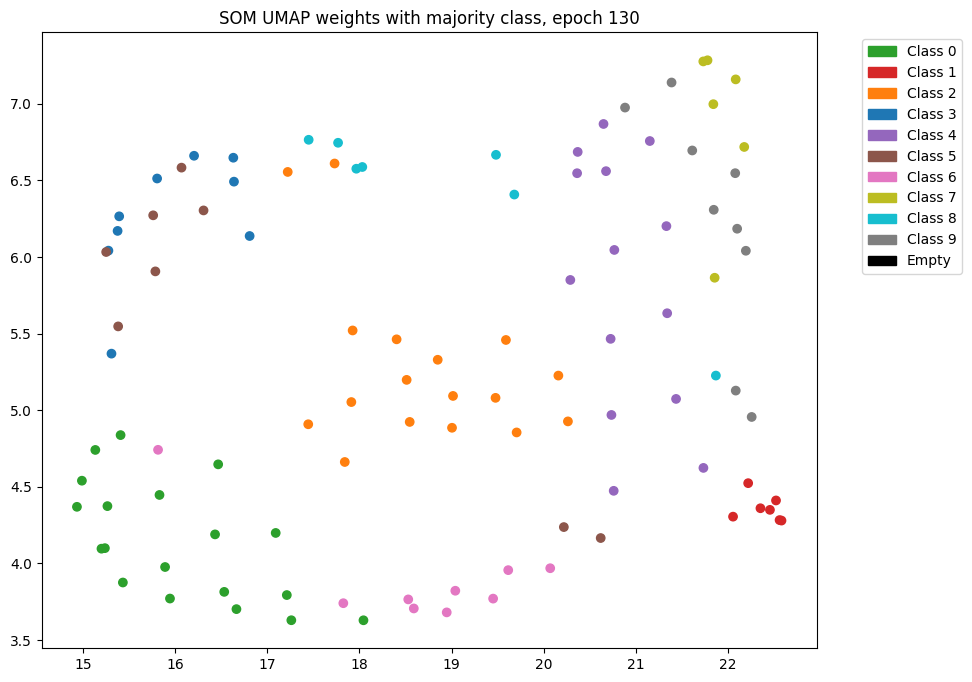

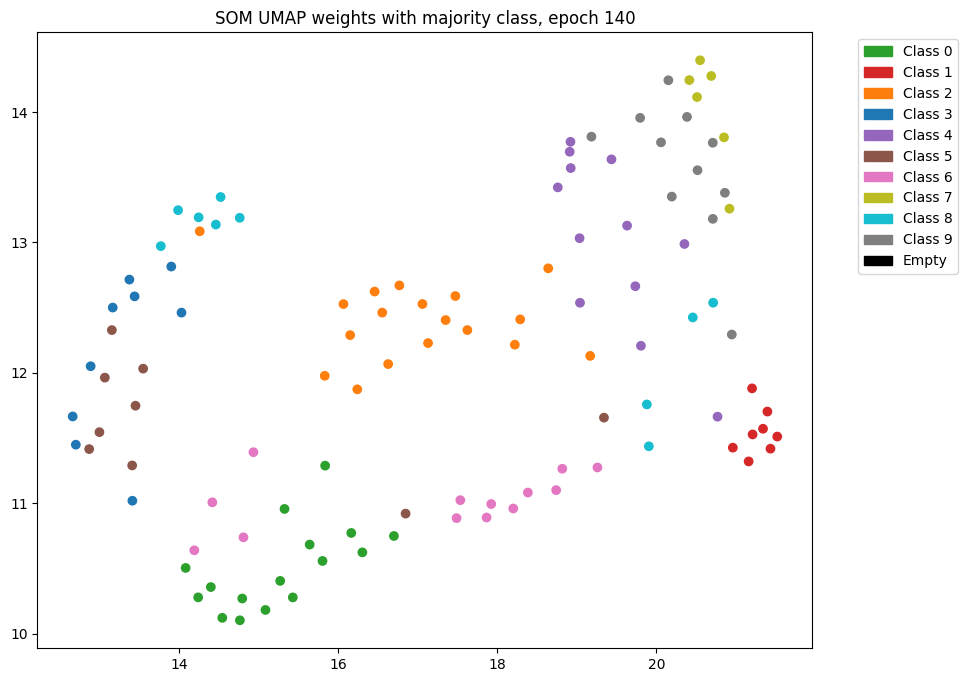

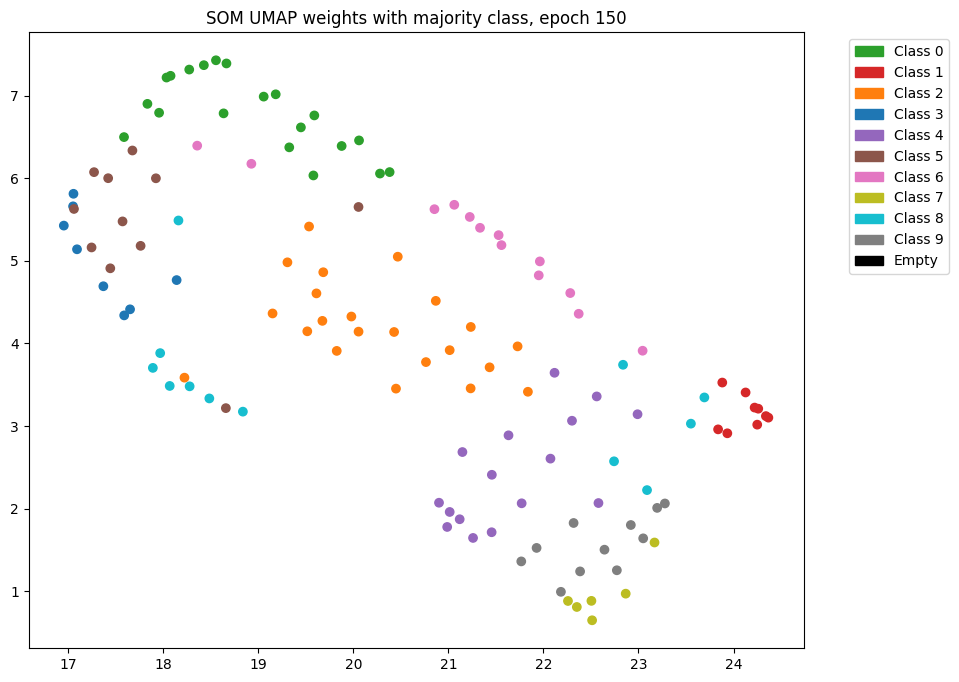

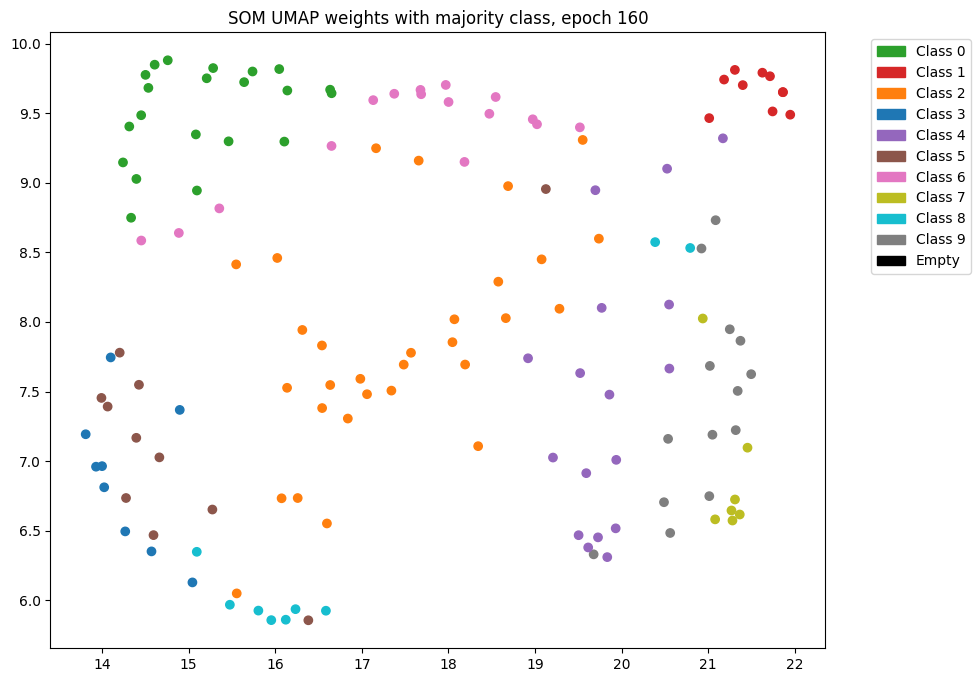

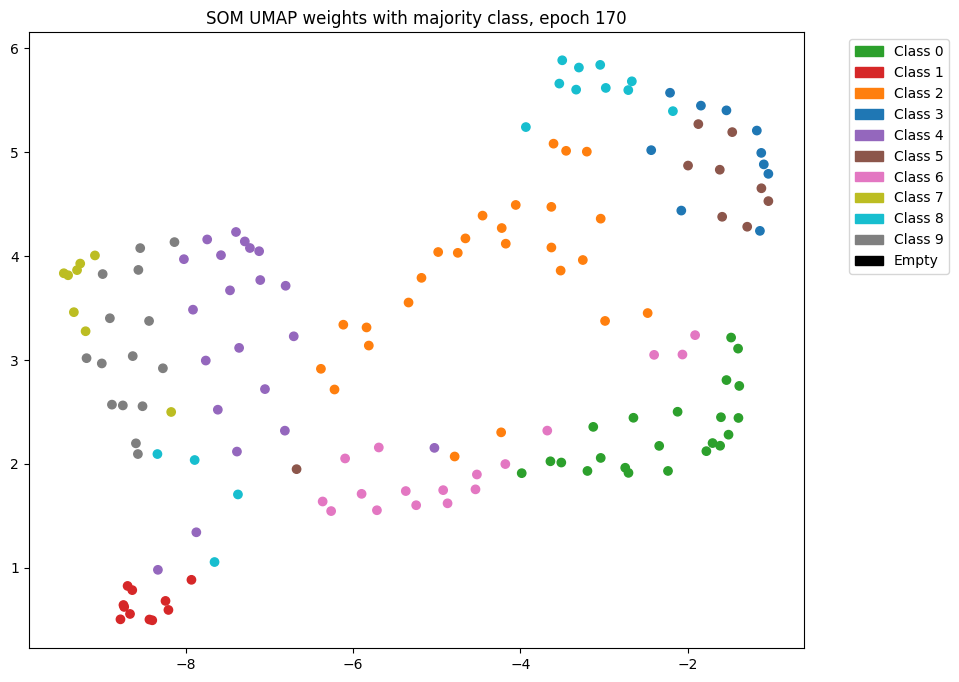

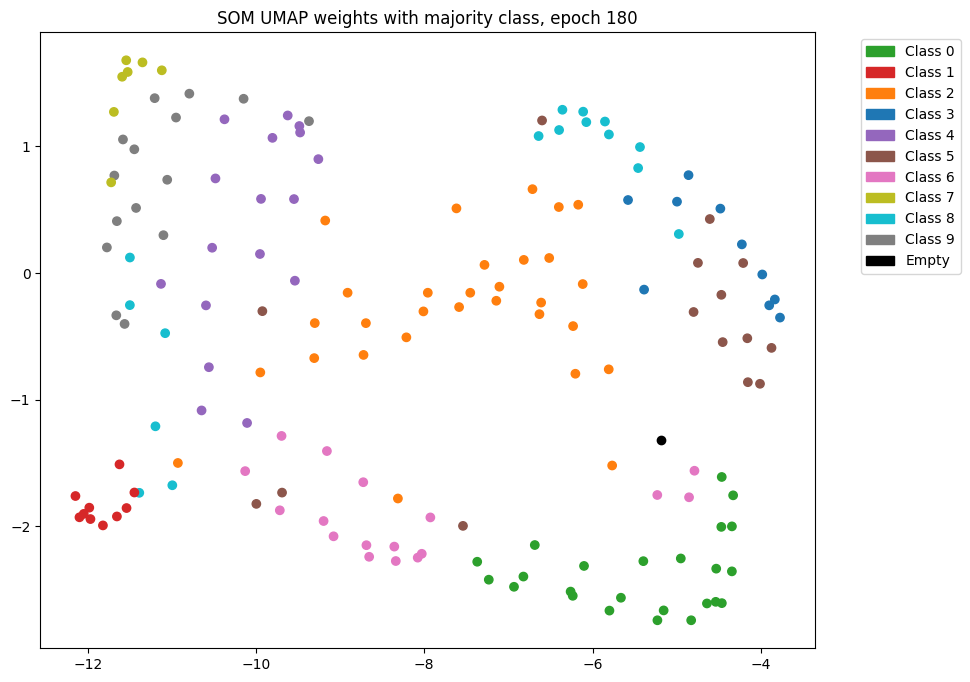

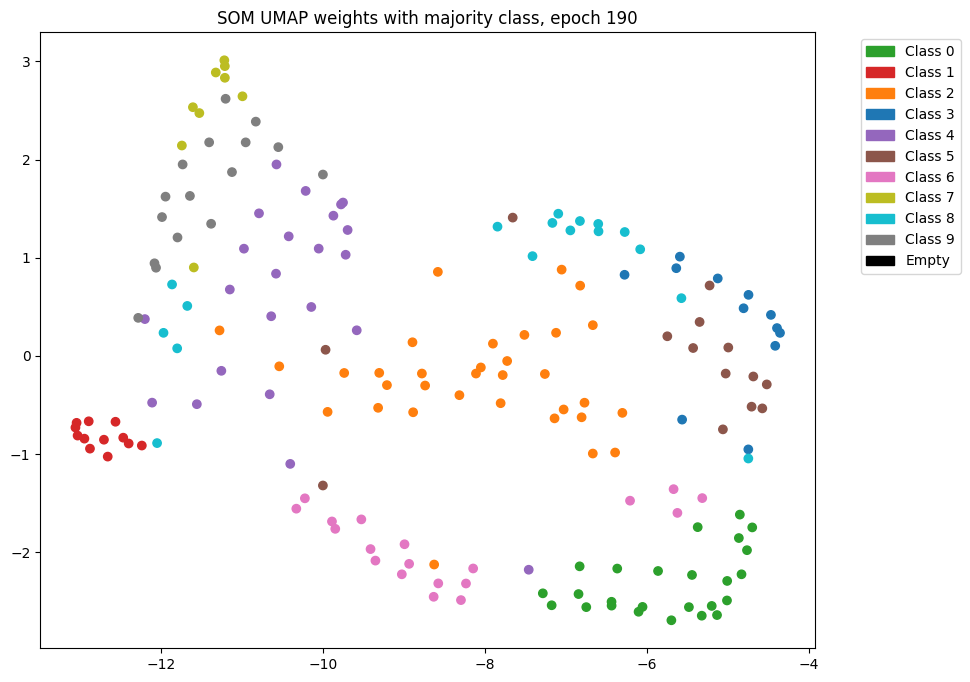

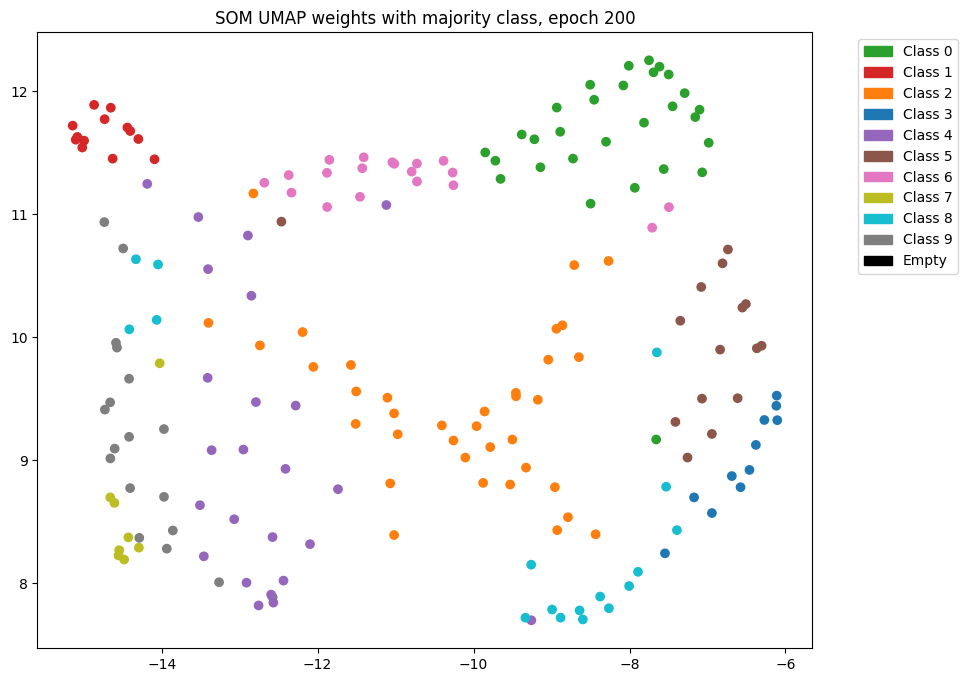

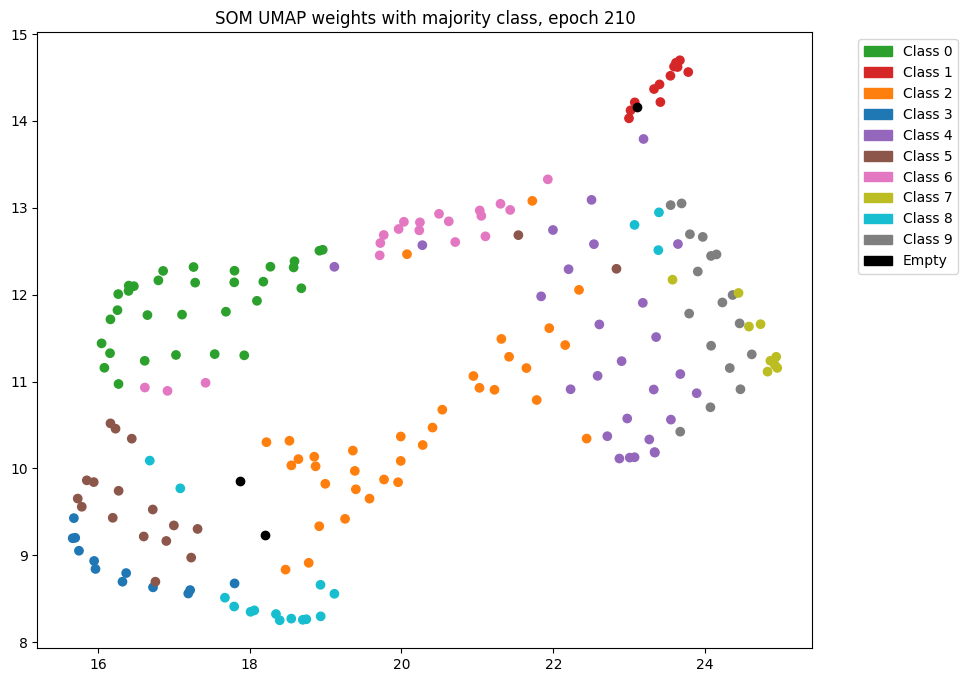

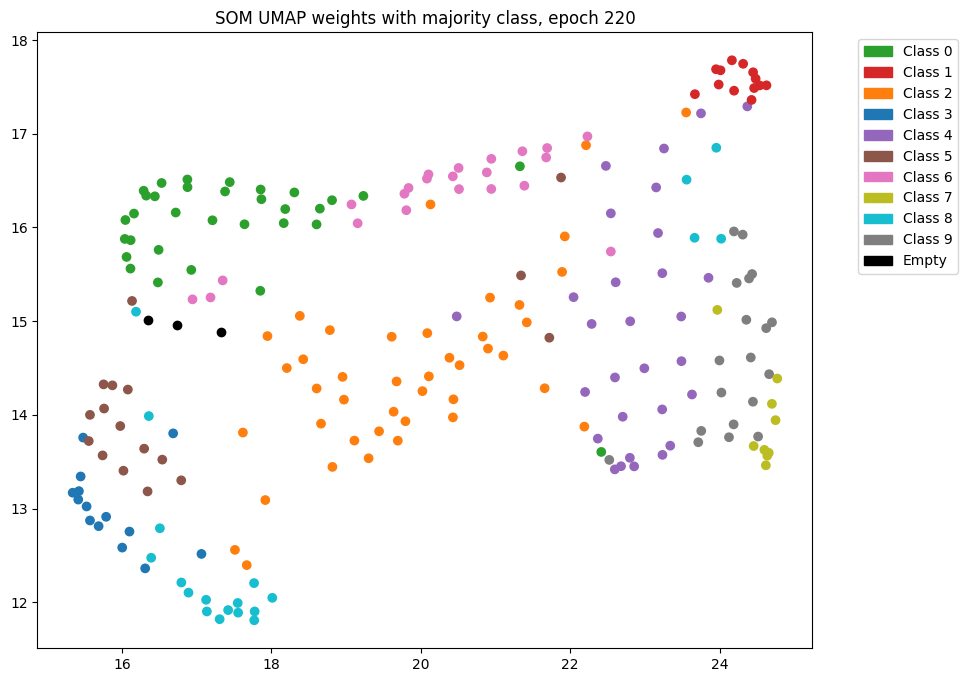

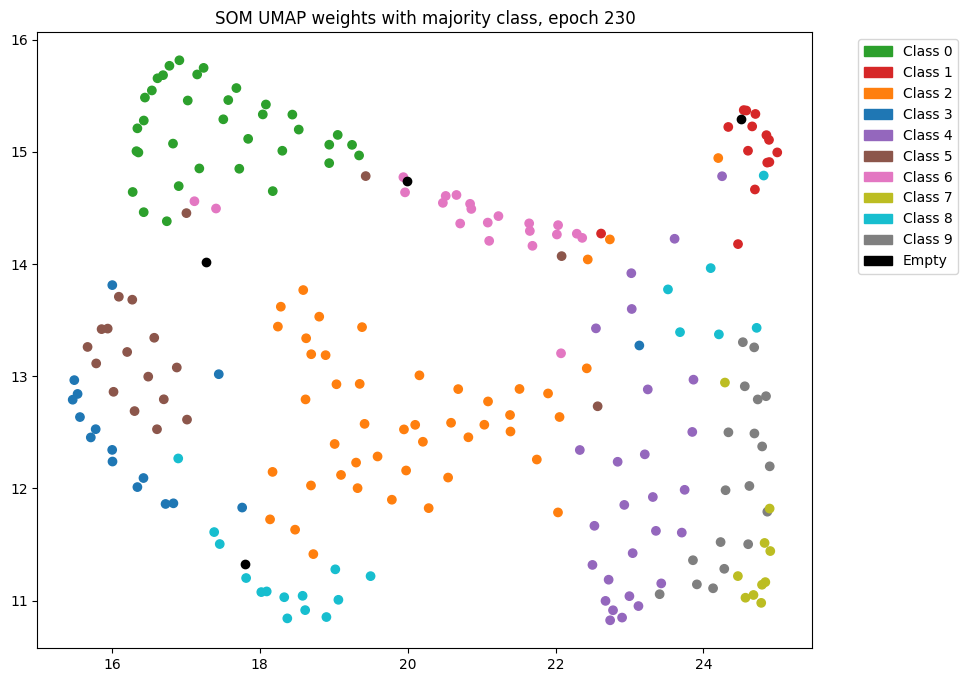

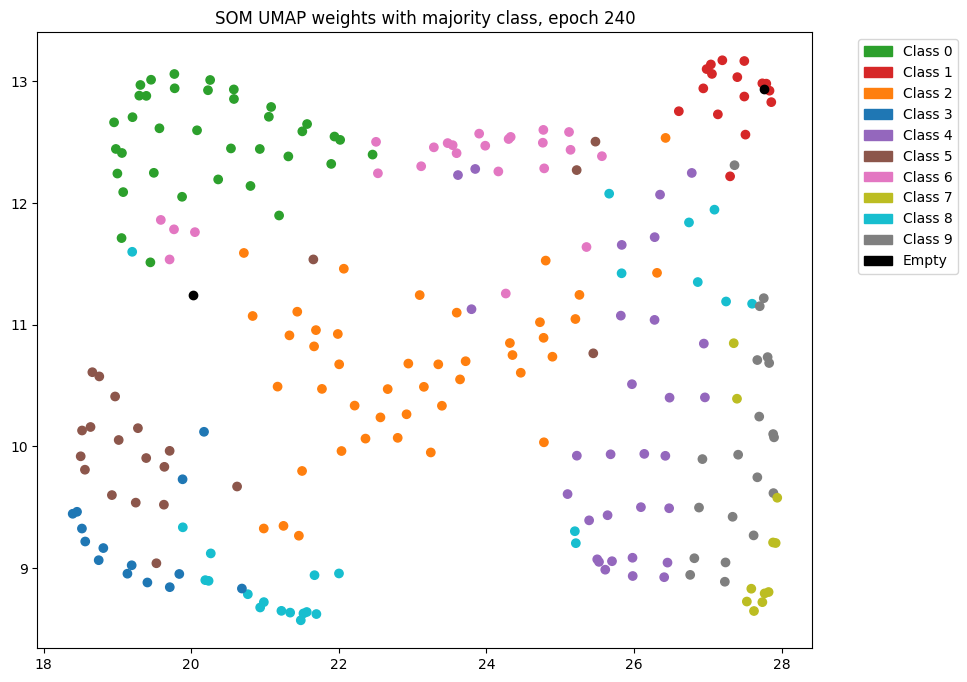

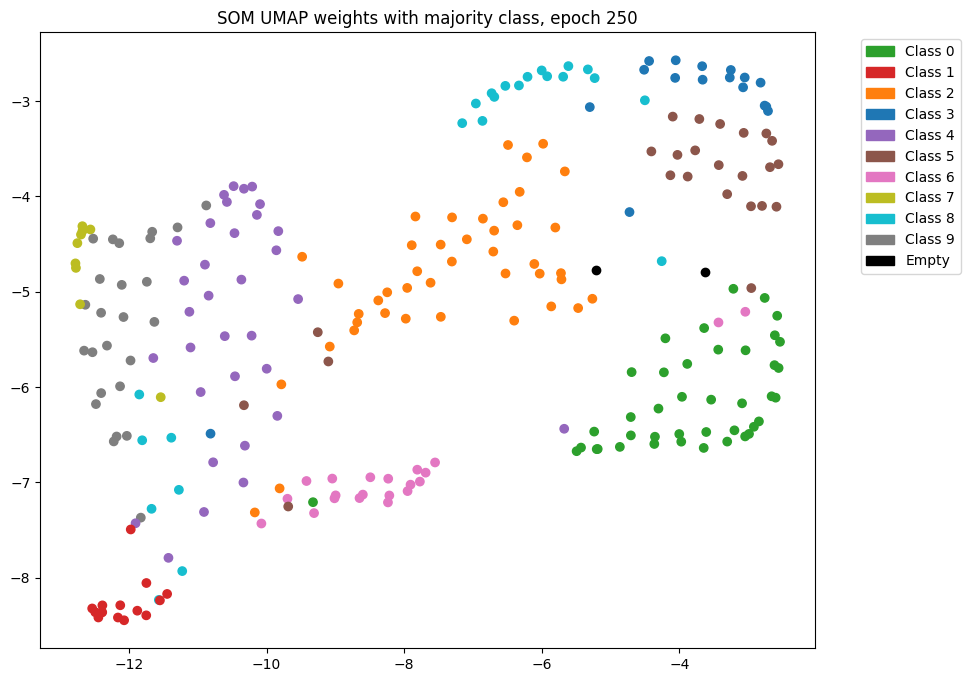

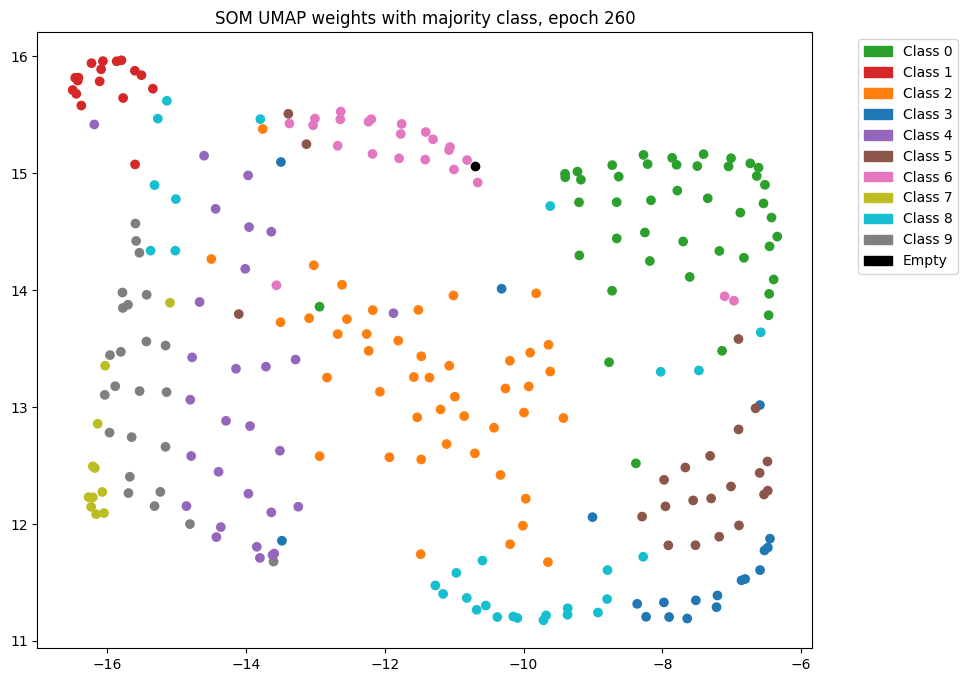

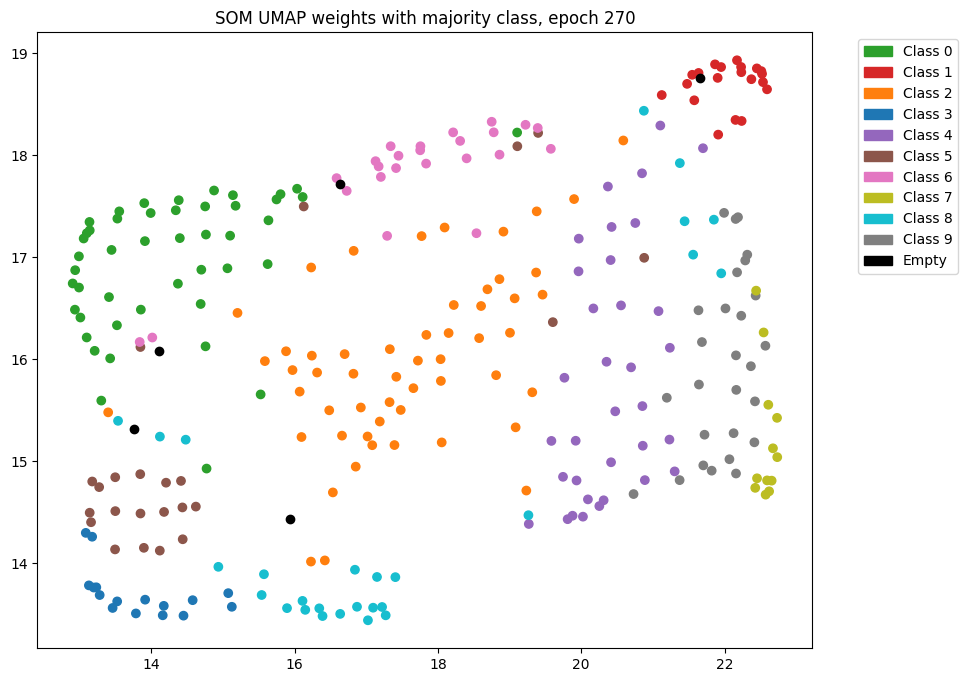

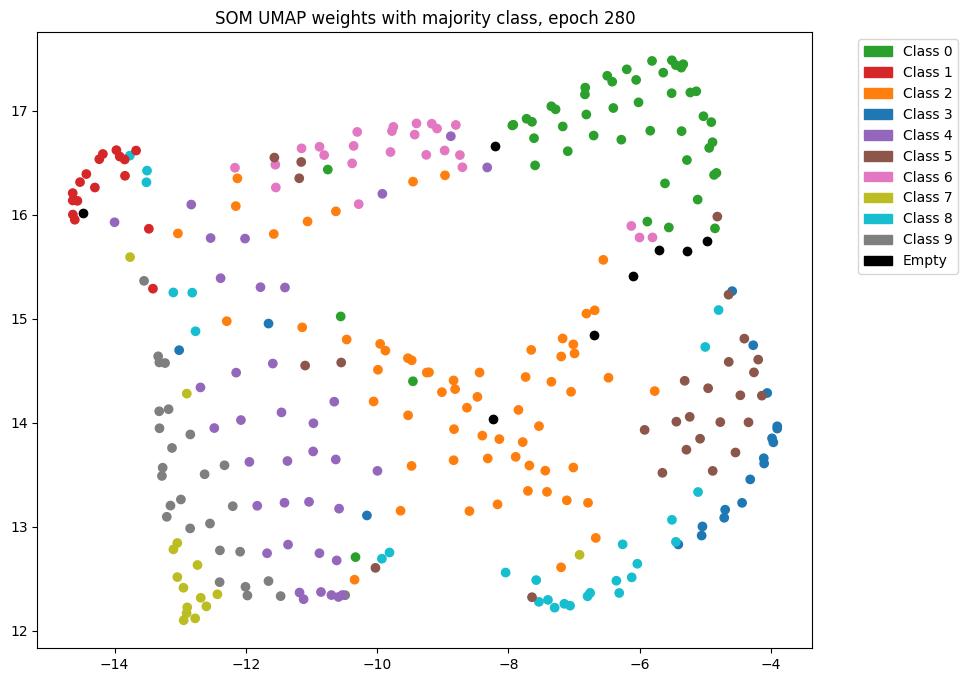

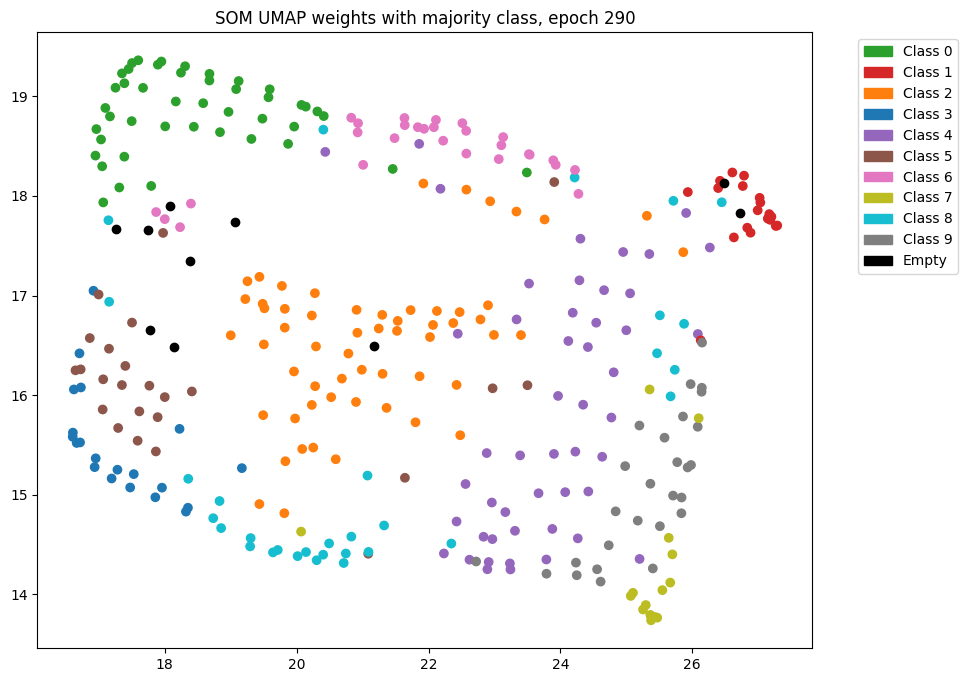

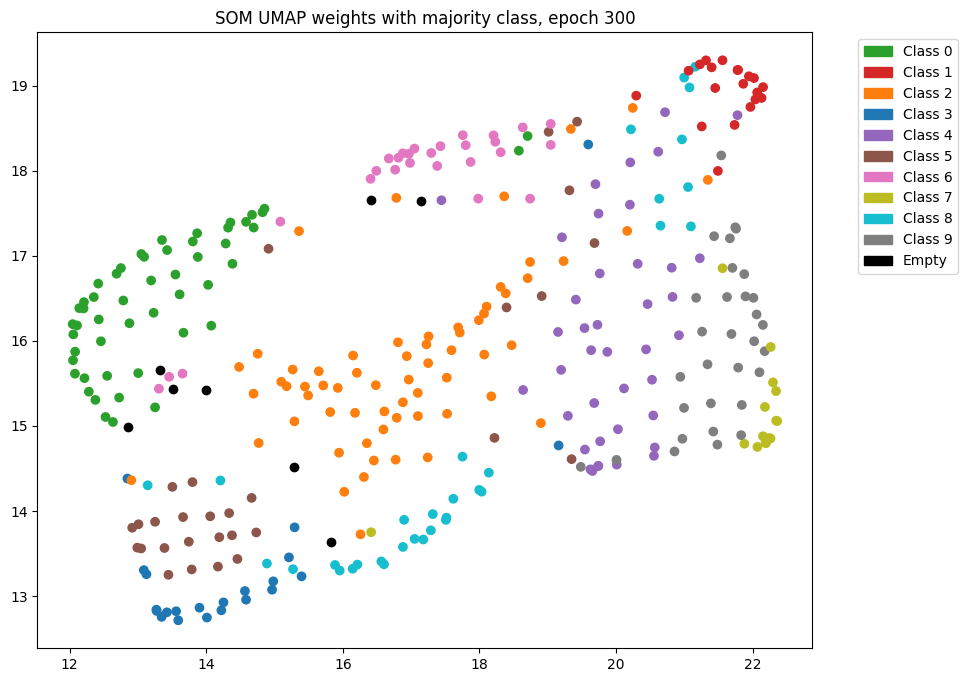

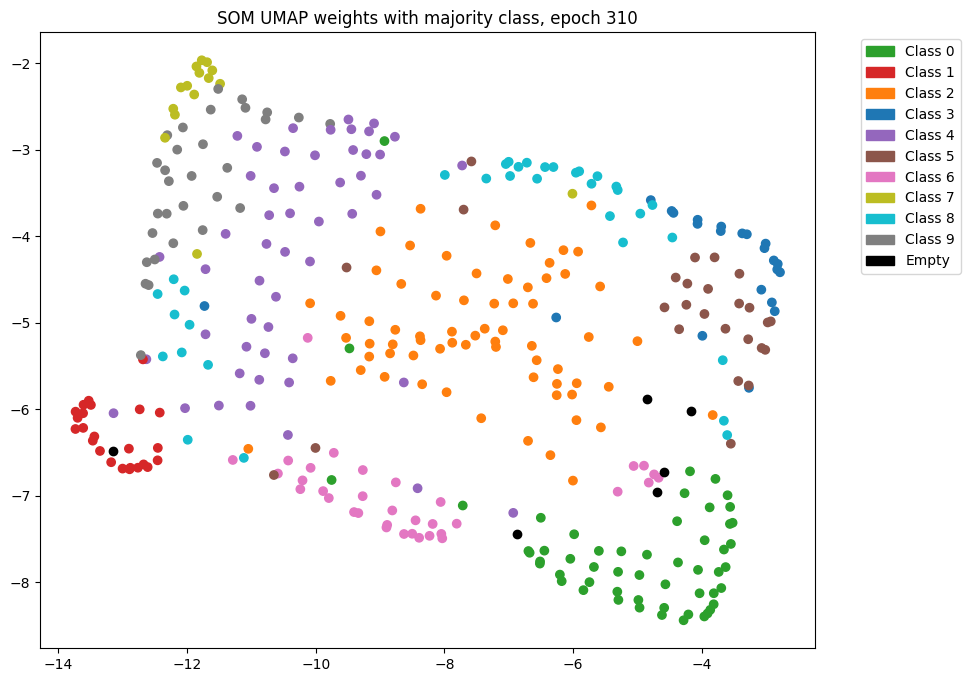

In [16]:
plot_umap_som_weights(snapshot_som_weights, unique_labels)

## Phase 3: ViT-GSOM Fine-Tuning

In [30]:
torch.save(autoencoder, "D:/Tom/ViT-GHSOM/model_usps.pth")

In [17]:
autoencoder = torch.load("D:/Tom/ViT-GHSOM/model.pth",weights_only=False)

In [43]:
final_rows, final_cols = autoencoder.get_som_shape()

autoencoder.som_weights.requires_grad = True
for param in autoencoder.encoder.parameters():
    param.requires_grad = False
for param in autoencoder.decoder.parameters():
    param.requires_grad = False

paramsSOM = autoencoder.get_som_weights()
optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['fine_tuning_epochs'], last_epoch=-1)

sigma_start = 2
sigma_end = 0.01
beta = (sigma_end / sigma_start) ** (1 / config['fine_tuning_epochs'])

grid_coords = get_grid_coords(autoencoder.current_row_num, autoencoder.current_col_num, device)
current_sigma = sigma_start

checkpoints = [i for i in range(0, config['fine_tuning_epochs'] + 1, 10)]
snapshot_som_weights_finetuning = {}
snapshot_som_weights_finetuning[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

history = {'som': [], 'purity': [], 'QE': [], 'TE': []}

print("Start training")
for epoch in range(config['fine_tuning_epochs']):
    
    running_som = 0.0
    
    sigma_t = decay_exponential(sigma_start, beta, epoch)
    last_sigma = sigma_t
    
    for images, _ in loader:
        images = images.to(device)
        
        reconstructed, latent, _ = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        
        optimizerSOM.zero_grad()
        l_som.backward()
        optimizerSOM.step()
        
        running_som += l_som.item()
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()

    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_som = running_som / len(loader)

    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config['fine_tuning_epochs']} | Sigma: {sigma_t:.3f} | SOM: {avg_som:.8f} | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")

    if epoch+1 in checkpoints:        
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights_finetuning[epoch+1] = (weights_np, labels_np)

Start training
Epoch 1/100 | Sigma: 2.000 | SOM: 0.88000744 | QE: 0.0334 | TE: 0.0153 | Purity: 0.88213
Epoch 2/100 | Sigma: 1.897 | SOM: 0.77958233 | QE: 0.0336 | TE: 0.0092 | Purity: 0.87406
Epoch 3/100 | Sigma: 1.799 | SOM: 0.69794310 | QE: 0.0331 | TE: 0.0082 | Purity: 0.87298
Epoch 4/100 | Sigma: 1.706 | SOM: 0.62727096 | QE: 0.0326 | TE: 0.0099 | Purity: 0.87610
Epoch 5/100 | Sigma: 1.618 | SOM: 0.56188973 | QE: 0.0320 | TE: 0.0108 | Purity: 0.87718
Epoch 6/100 | Sigma: 1.535 | SOM: 0.50234045 | QE: 0.0315 | TE: 0.0113 | Purity: 0.87933
Epoch 7/100 | Sigma: 1.455 | SOM: 0.44851509 | QE: 0.0309 | TE: 0.0104 | Purity: 0.88277
Epoch 8/100 | Sigma: 1.380 | SOM: 0.40042722 | QE: 0.0304 | TE: 0.0132 | Purity: 0.88535
Epoch 9/100 | Sigma: 1.309 | SOM: 0.35719005 | QE: 0.0299 | TE: 0.0147 | Purity: 0.88826
Epoch 10/100 | Sigma: 1.241 | SOM: 0.31829010 | QE: 0.0293 | TE: 0.0145 | Purity: 0.89019
Epoch 11/100 | Sigma: 1.177 | SOM: 0.28361932 | QE: 0.0289 | TE: 0.0144 | Purity: 0.89363
Epoc

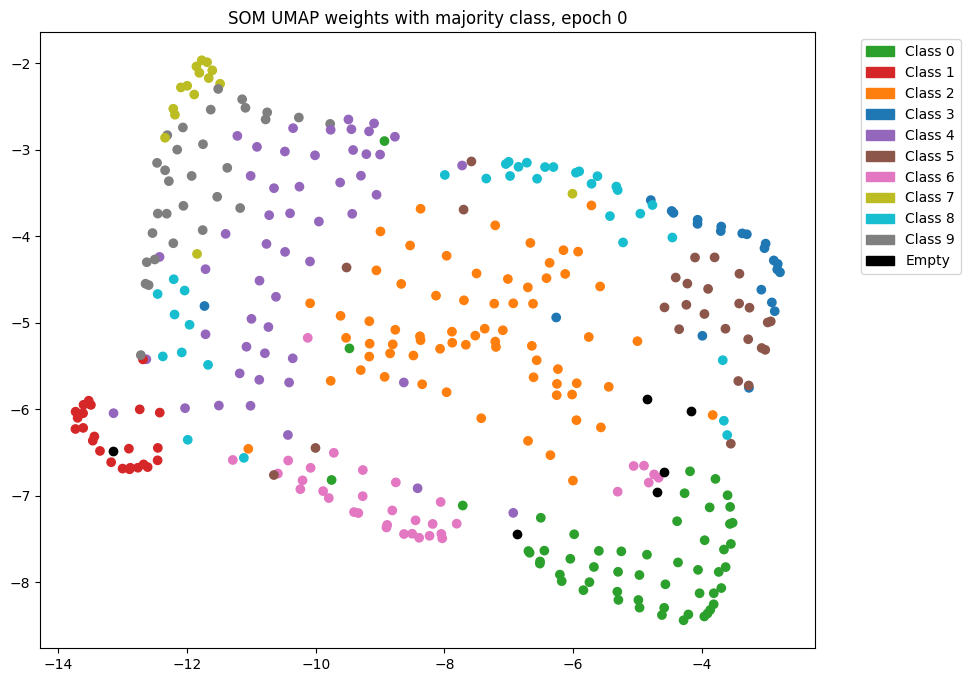

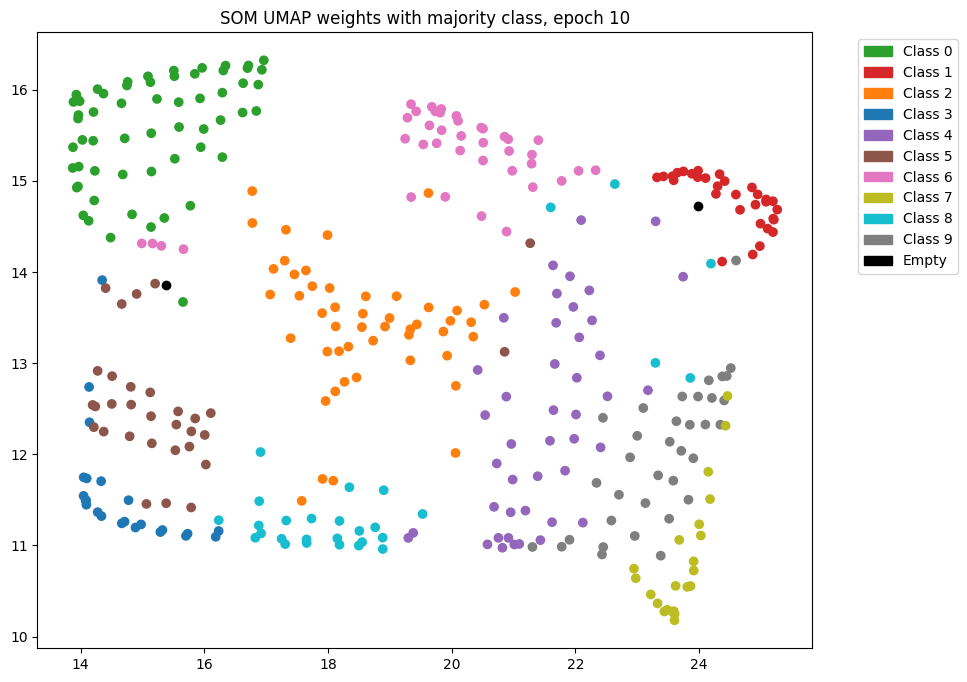

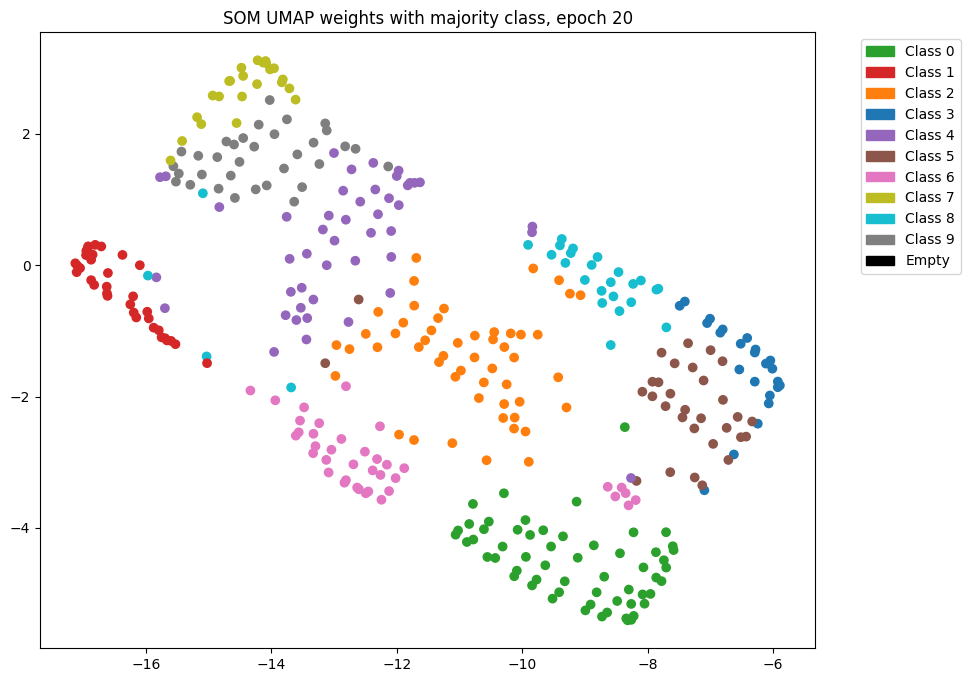

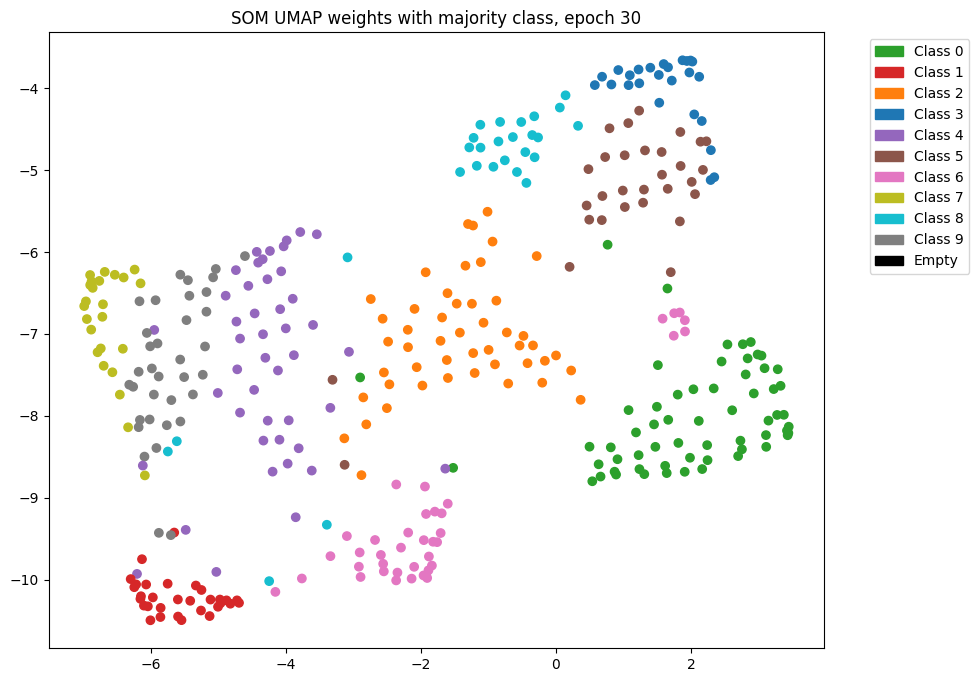

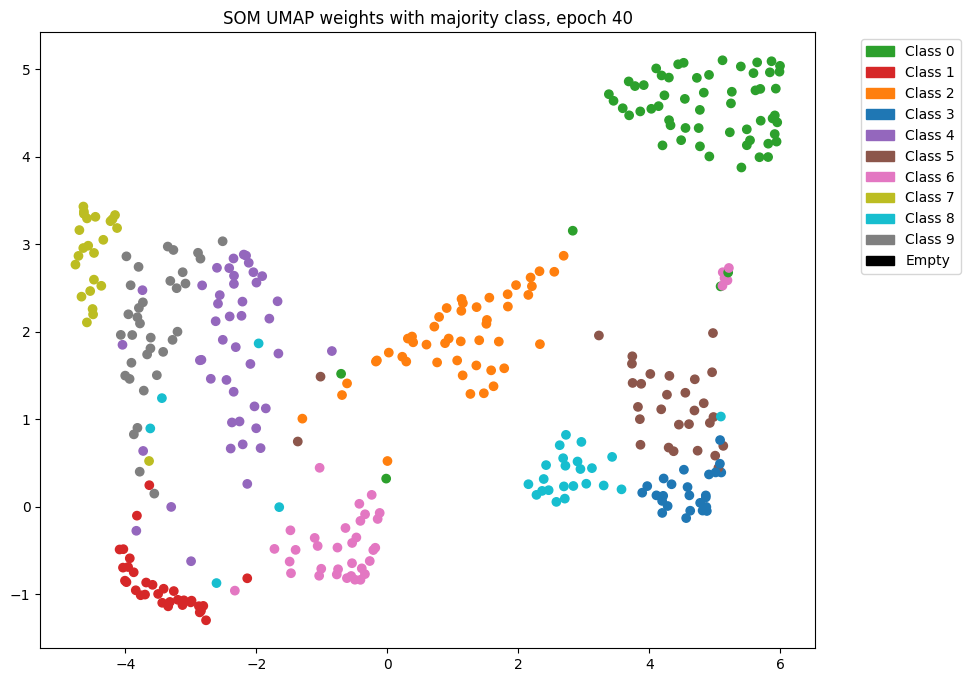

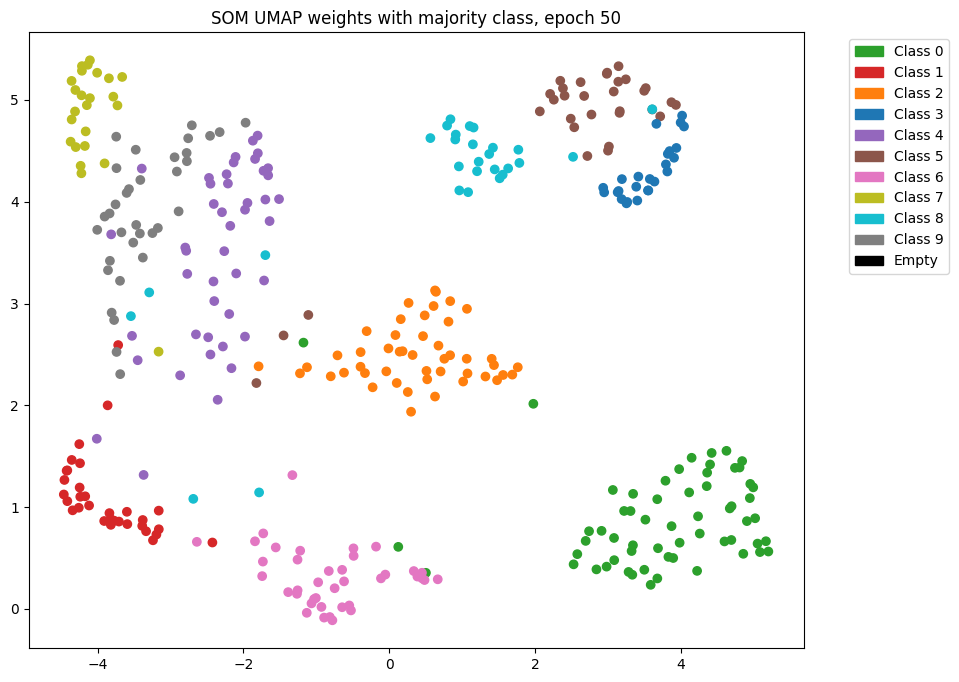

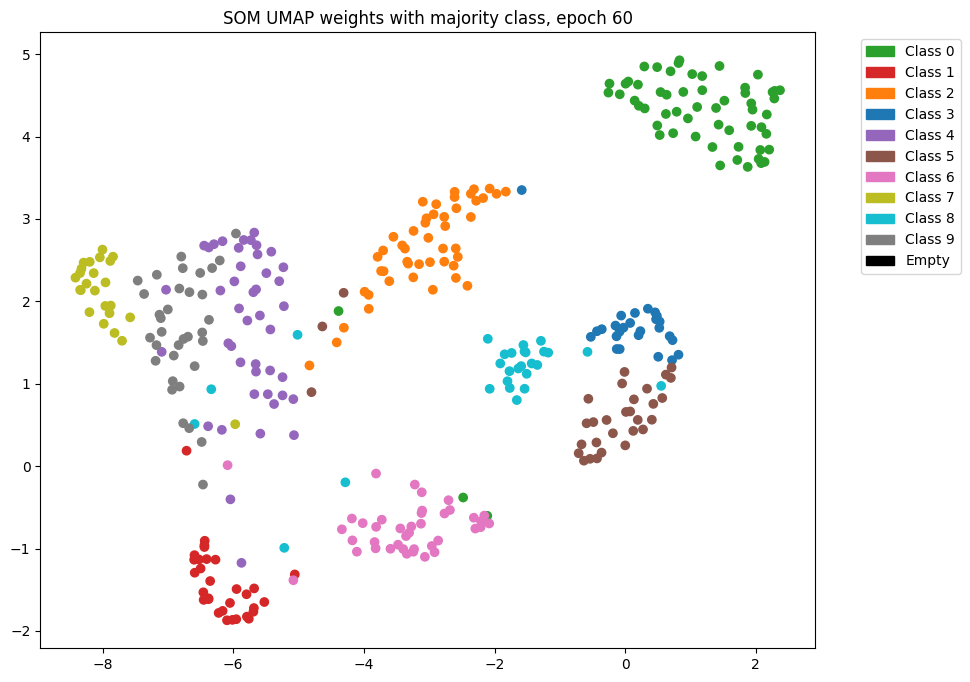

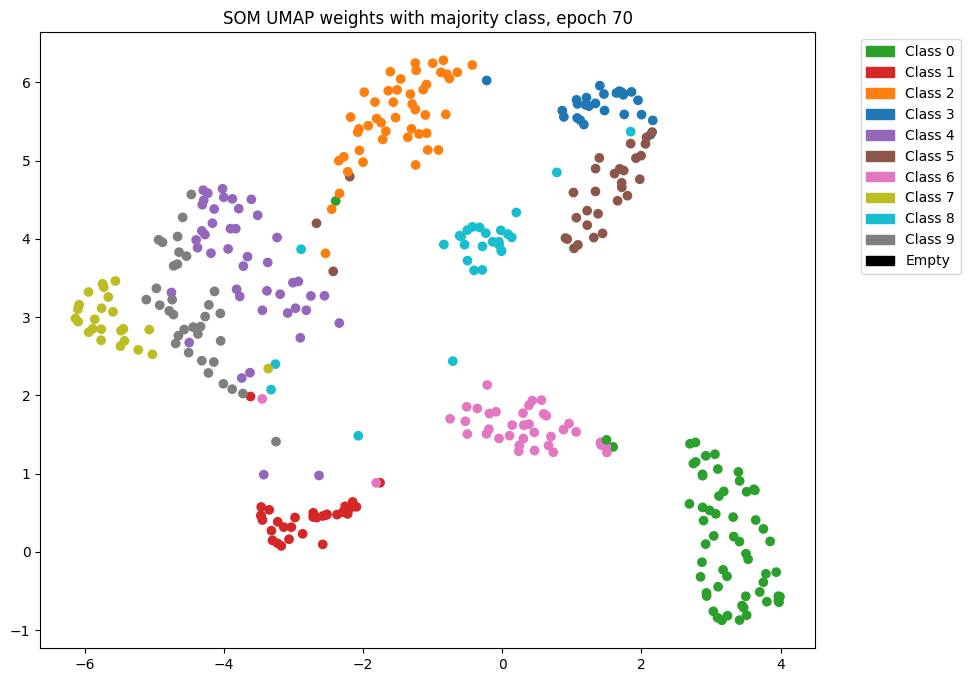

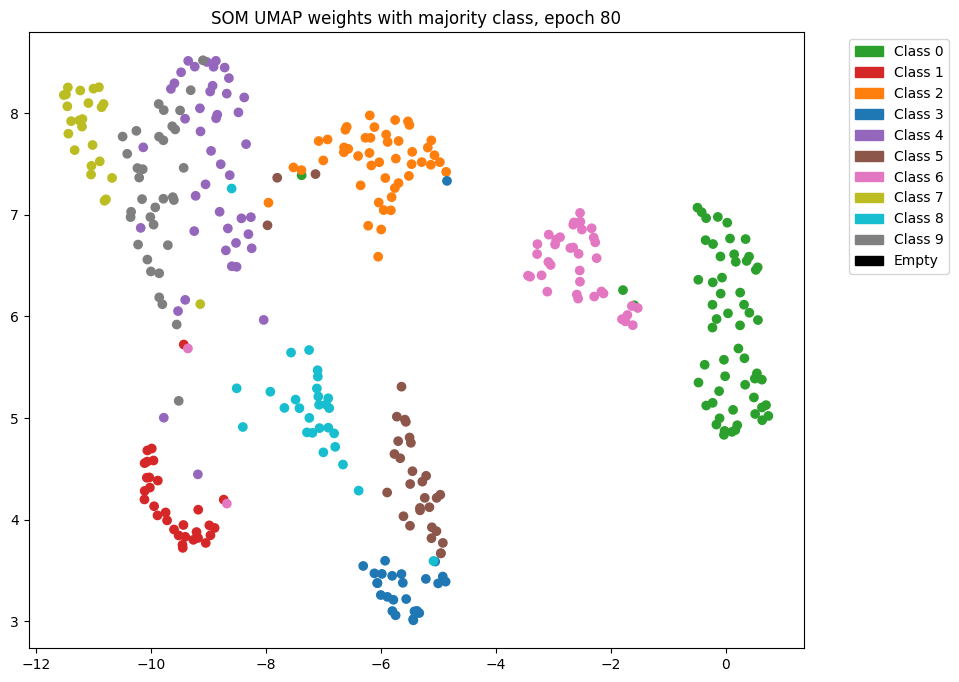

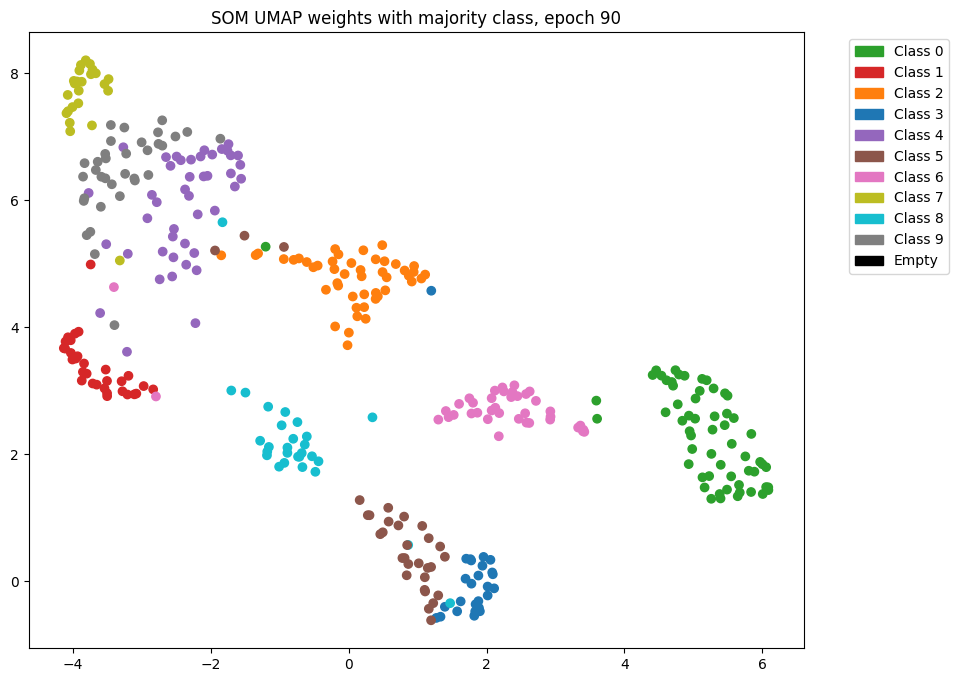

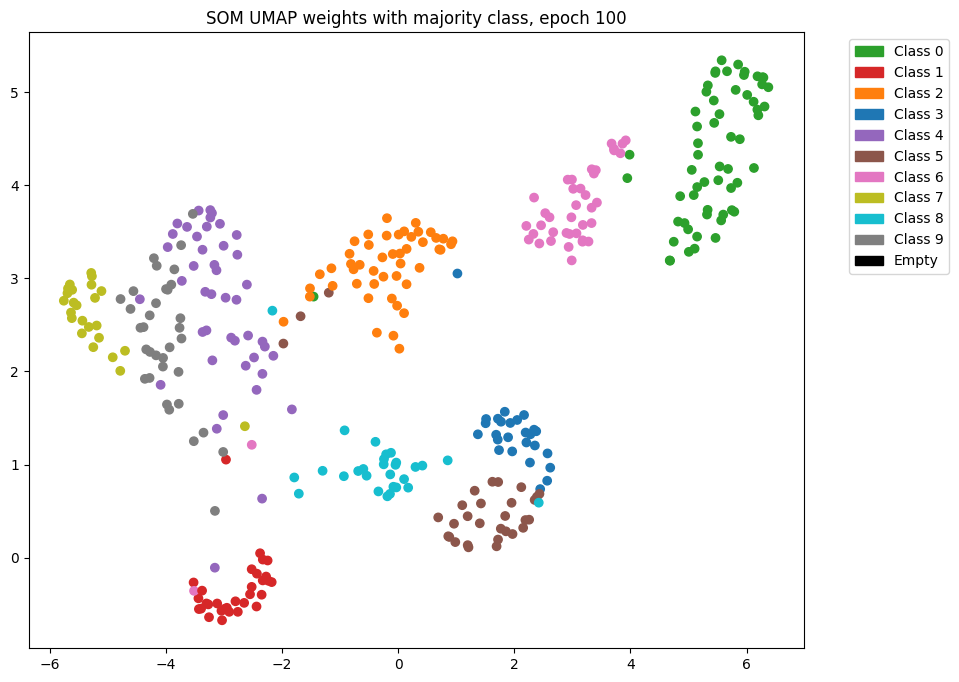

In [44]:
plot_umap_som_weights(snapshot_som_weights_finetuning, unique_labels)

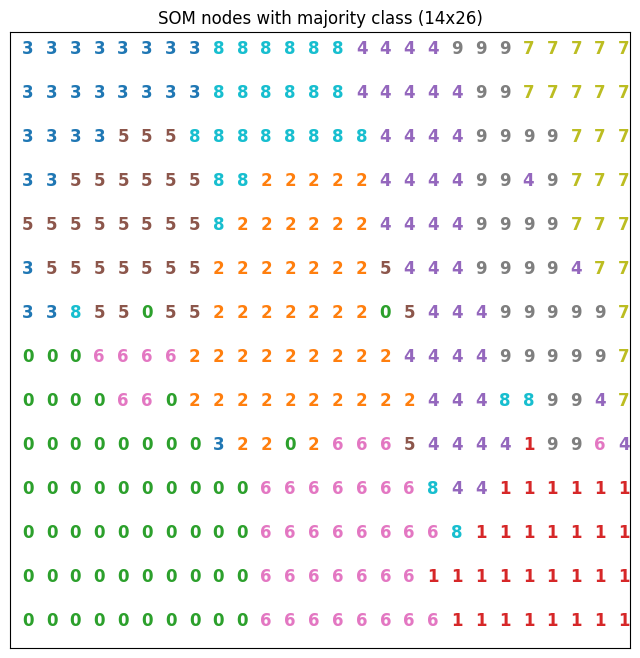

In [45]:
plot_som_mnist(snapshot_som_weights_finetuning, final_rows, final_cols)

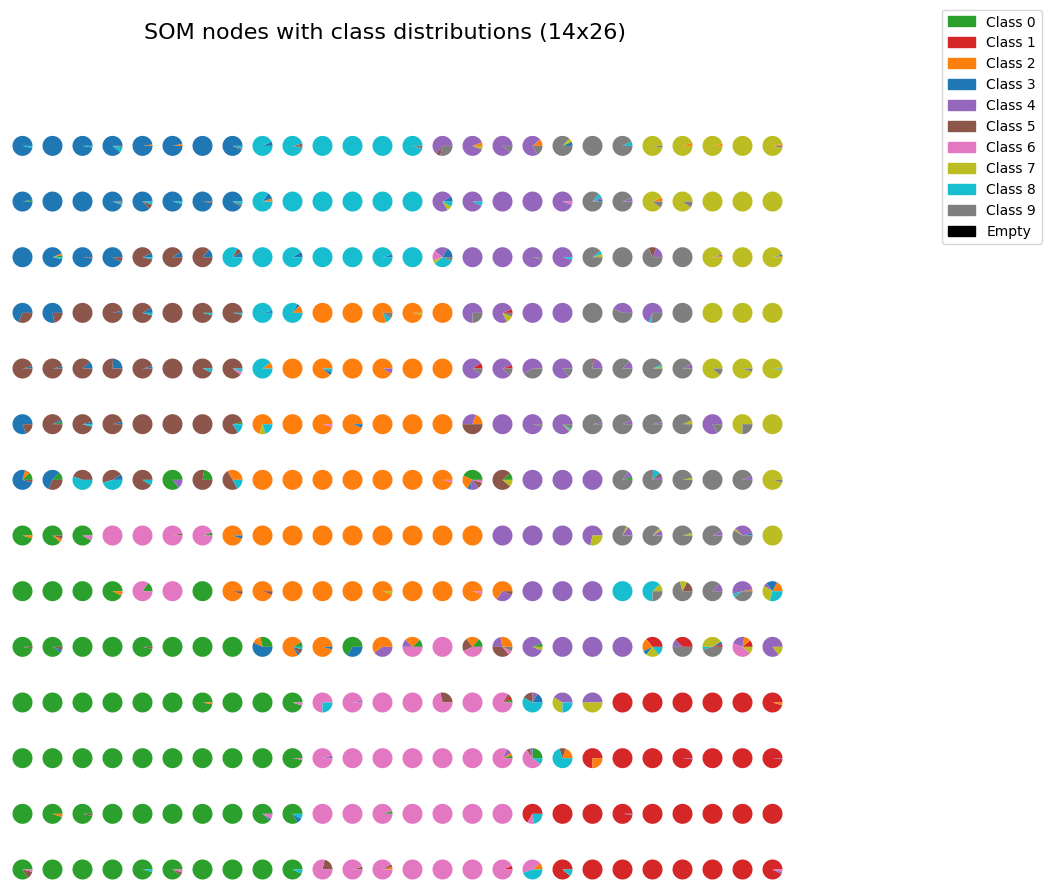

In [46]:
plot_som_pie_grid(snapshot_som_weights_finetuning, final_rows, final_cols, unique_labels)

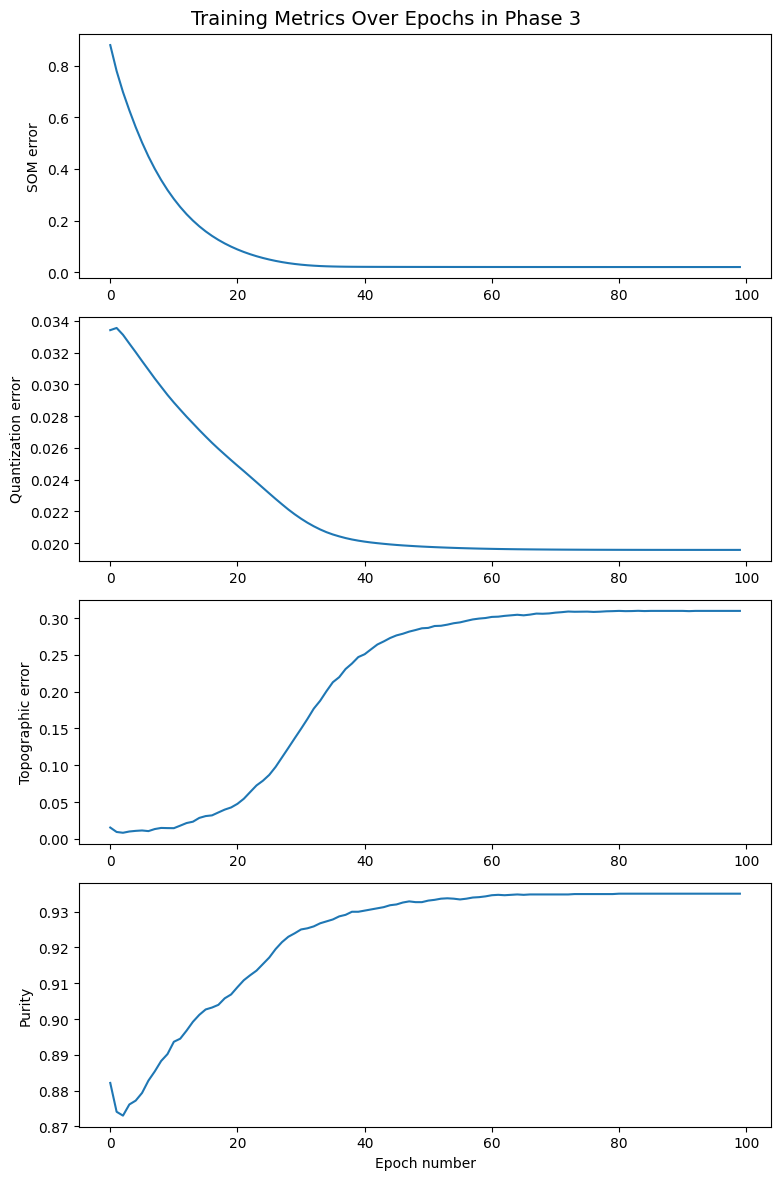

In [49]:
epochs_completed = len(history['QE'])
x = np.arange(epochs_completed)

plt.figure(figsize=(8, 12))

ax = plt.subplot(4,1,1)
plt.plot(x, history['som'])
plt.ylabel('SOM error')


ax = plt.subplot(4,1,2)
plt.plot(x, history['QE'])
plt.ylabel('Quantization error')


ax = plt.subplot(4,1,3)
plt.plot(x, history['TE'])
plt.ylabel('Topographic error')

ax = plt.subplot(4,1,4)
plt.plot(x, history['purity'])
plt.ylabel('Purity')

plt.xlabel('Epoch number')
plt.suptitle("Training Metrics Over Epochs in Phase 3", fontsize=14)
plt.tight_layout()
plt.show()